# Phase-I optimization-versus-adaptivity analysis

## 1. Analysis questions

This notebook analyzes the completed paired-split experiment without
rerunning acquisition. It asks:

1. Does DAPRO improve coverage calibration, inverse-weight behavior, and
   weighted-loss variance beyond generic score adaptivity?
2. How does DAPRO compare with the existing locally adaptive shadow-price policy?
3. In which trajectory strata do the gains concentrate?
4. Do the methods meet the same total calibration-budget target?

All inferential comparisons are paired by `split_id`. Conclusions below
are generated from the loaded data and explicitly retain inconclusive results.

## 2. Configuration and imports

In [1]:
from pathlib import Path
import hashlib
import json
import math
import platform
import sys
import warnings

import torch
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
from scipy.stats import spearmanr, wilcoxon
from IPython.display import Markdown, display


# Parameters: paths work when execution starts in the repository root or notebooks/.
RESULTS_DIR = Path("../results/phase1_optimization_ablation")
OUTPUT_DIR = RESULTS_DIR / "notebook_analysis"
BOOTSTRAP_RESAMPLES = 10_000
BOOTSTRAP_SEED = 1729
TEST_ALPHA = 0.05
STRICT_RESOLUTION_VALIDATION = False

EXPECTED_METHODS = [
    "Static",
    "RandomAdaptive",
    "ScoreAdaptive-Heuristic",
    "LocallyAdaptive",
    "DAPRO",
]
METHOD_ORDER = EXPECTED_METHODS
PRIMARY_COMPARISONS = [
    ("DAPRO", "ScoreAdaptive-Heuristic"),
    ("DAPRO", "LocallyAdaptive"),
]
DAPRO_COMPARISONS = [
    ("DAPRO", "ScoreAdaptive-Heuristic"),
    ("DAPRO", "RandomAdaptive"),
    ("DAPRO", "LocallyAdaptive"),
    ("DAPRO", "Static"),
]
SECONDARY_COMPARISONS = [
    ("ScoreAdaptive-Heuristic", "RandomAdaptive"),
    ("RandomAdaptive", "Static"),
    ("LocallyAdaptive", "Static"),
]
ALL_COMPARISONS = DAPRO_COMPARISONS + SECONDARY_COMPARISONS
PRIMARY_METRICS = [
    "absolute_coverage_deviation_pp",
    "phase2_mean_latent_terminal_weight",
    "weighted_miscoverage_variance",
]
COLORS = {
    "Static": "#4C78A8",
    "RandomAdaptive": "#F58518",
    "ScoreAdaptive-Heuristic": "#54A24B",
    "LocallyAdaptive": "#E45756",
    "DAPRO": "#B279A2",
}
SHORT_NAMES = {
    "Static": "Static",
    "RandomAdaptive": "Random",
    "ScoreAdaptive-Heuristic": "Score heuristic",
    "LocallyAdaptive": "Local",
    "DAPRO": "DAPRO",
}

cwd = Path.cwd().resolve()
candidates = [
    (cwd / RESULTS_DIR).resolve(),
    (cwd / "results" / "phase1_optimization_ablation").resolve(),
    (cwd.parent / "results" / "phase1_optimization_ablation").resolve(),
]
RESULTS_DIR = next(
    (candidate for candidate in candidates if (candidate / "split_level_results.csv").exists()),
    candidates[0],
)
OUTPUT_DIR = RESULTS_DIR / "notebook_analysis"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
PROJECT_ROOT = RESULTS_DIR.parents[1]
validation_warnings = []

available_style = (
    "seaborn-v0_8-whitegrid"
    if "seaborn-v0_8-whitegrid" in plt.style.available
    else "seaborn-whitegrid"
)
plt.style.use(available_style)
plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "legend.fontsize": 8,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

print(f"Results: {RESULTS_DIR}")
print(f"Notebook outputs: {OUTPUT_DIR}")

Results: C:\Users\Shai1\Documents\projects\dapro_rebuttal\results\phase1_optimization_ablation
Notebook outputs: C:\Users\Shai1\Documents\projects\dapro_rebuttal\results\phase1_optimization_ablation\notebook_analysis


In [2]:
def mean_se(values):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    if not len(values):
        return math.nan, math.nan
    se = np.std(values, ddof=1) / np.sqrt(len(values)) if len(values) > 1 else 0.0
    return float(np.mean(values)), float(se)


def bootstrap_mean_ci(values, seed, resamples=BOOTSTRAP_RESAMPLES):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    if not len(values):
        return math.nan, math.nan
    if len(values) == 1:
        return float(values[0]), float(values[0])
    rng = np.random.default_rng(seed)
    means = []
    remaining = resamples
    while remaining:
        current = min(1_000, remaining)
        idx = rng.integers(0, len(values), size=(current, len(values)))
        means.append(values[idx].mean(axis=1))
        remaining -= current
    return tuple(float(x) for x in np.quantile(np.concatenate(means), [0.025, 0.975]))


def holm_adjust(p_values):
    p_values = np.asarray(p_values, dtype=float)
    adjusted = np.full(len(p_values), np.nan)
    finite = np.flatnonzero(np.isfinite(p_values))
    if not len(finite):
        return adjusted
    order = finite[np.argsort(p_values[finite])]
    running = 0.0
    m = len(order)
    for rank, idx in enumerate(order):
        running = max(running, (m - rank) * p_values[idx])
        adjusted[idx] = min(1.0, running)
    return adjusted


def paired_wilcoxon(values):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    if not len(values) or np.allclose(values, 0.0):
        return 1.0
    try:
        return float(wilcoxon(values, alternative="two-sided", zero_method="wilcox").pvalue)
    except ValueError:
        return 1.0


def gini(values):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    if not len(values) or np.sum(values) <= 0:
        return math.nan
    values = np.sort(values)
    n = len(values)
    return float((2 * np.sum(np.arange(1, n + 1) * values) / (n * values.sum())) - (n + 1) / n)


def markdown_table(headers, rows):
    return "\n".join([
        "| " + " | ".join(headers) + " |",
        "|" + "|".join(["---" if i == 0 else "---:" for i in range(len(headers))]) + "|",
        *["| " + " | ".join(map(str, row)) + " |" for row in rows],
    ])


def counted_markdown(text):
    text = text.rstrip()
    count = -1
    while True:
        rendered = f"{text}\n\n<!-- character_count: {count} -->\n"
        new_count = len(rendered)
        if new_count == count:
            return rendered
        count = new_count


def stable_file_state(path):
    stat = path.stat()
    return {"size": stat.st_size, "mtime_ns": stat.st_mtime_ns}


def save_figure(fig, stem):
    png = OUTPUT_DIR / f"{stem}.png"
    pdf = OUTPUT_DIR / f"{stem}.pdf"
    fig.savefig(png, bbox_inches="tight")
    fig.savefig(pdf, bbox_inches="tight")
    return png, pdf


def json_value(value):
    if isinstance(value, (np.integer,)):
        return int(value)
    if isinstance(value, (np.floating,)):
        return None if not np.isfinite(value) else float(value)
    if isinstance(value, np.ndarray):
        return [json_value(item) for item in value.tolist()]
    if isinstance(value, dict):
        return {str(key): json_value(item) for key, item in value.items()}
    if isinstance(value, (list, tuple)):
        return [json_value(item) for item in value]
    return value


def bootstrap_variance_ci(values, seed, resamples=BOOTSTRAP_RESAMPLES):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    if len(values) < 2:
        return math.nan, math.nan
    rng = np.random.default_rng(seed)
    estimates = []
    remaining = resamples
    while remaining:
        current = min(1_000, remaining)
        idx = rng.integers(0, len(values), size=(current, len(values)))
        estimates.append(np.var(values[idx], axis=1, ddof=1))
        remaining -= current
    return tuple(float(x) for x in np.quantile(np.concatenate(estimates), [0.025, 0.975]))


def bootstrap_paired_variance_difference(first, second, seed, resamples=BOOTSTRAP_RESAMPLES):
    first = np.asarray(first, dtype=float)
    second = np.asarray(second, dtype=float)
    finite = np.isfinite(first) & np.isfinite(second)
    first, second = first[finite], second[finite]
    if len(first) < 2:
        return math.nan, math.nan
    rng = np.random.default_rng(seed)
    estimates = []
    remaining = resamples
    while remaining:
        current = min(1_000, remaining)
        idx = rng.integers(0, len(first), size=(current, len(first)))
        estimates.append(
            np.var(first[idx], axis=1, ddof=1)
            - np.var(second[idx], axis=1, ddof=1)
        )
        remaining -= current
    return tuple(float(x) for x in np.quantile(np.concatenate(estimates), [0.025, 0.975]))


## 3. Load and validate outputs

In [3]:
split_path = RESULTS_DIR / "split_level_results.csv"
sample_path = RESULTS_DIR / "sample_level_results.csv"
metadata_path = RESULTS_DIR / "run_metadata.json"
missing_raw = [str(path) for path in (split_path, sample_path) if not path.exists()]
if missing_raw:
    raise FileNotFoundError(
        "Required completed-experiment outputs are missing: " + ", ".join(missing_raw)
    )
raw_file_state = {
    str(split_path): stable_file_state(split_path),
    str(sample_path): stable_file_state(sample_path),
}
metadata = json.loads(metadata_path.read_text()) if metadata_path.exists() else None
if metadata is None:
    validation_warnings.append(
        "run_metadata.json is unavailable; total calibration budget cannot be reconstructed."
    )

split_df = pd.read_csv(split_path)
sample_columns = [
    "split_id", "sample_id", "method", "T_i", "q_prior_i", "b_i",
    "initial_score", "realized_cost", "censoring_time", "resolved_indicator",
    "event_observed_indicator", "latent_terminal_weight",
    "log_latent_terminal_weight", "difficulty_stratum",
    "initial_score_quartile",
]
optional_sample_columns = [
    "selected_lpb", "selected_latent_miscoverage_indicator",
    "selected_estimable_miscoverage_indicator",
    "selected_weighted_miscoverage_contribution",
    "conditional_acquisition_variance_term",
]
available_sample_columns = set(pd.read_csv(sample_path, nrows=0).columns)
sample_columns += [
    column for column in optional_sample_columns if column in available_sample_columns
]
sample_df = pd.read_csv(sample_path, usecols=sample_columns)
for column in ("method", "difficulty_stratum", "initial_score_quartile"):
    sample_df[column] = sample_df[column].astype("category")

# One split-level row per expected method.
split_counts = split_df.groupby("split_id")["method"].agg(["size", "nunique"])
assert split_counts["size"].eq(len(EXPECTED_METHODS)).all()
assert split_counts["nunique"].eq(len(EXPECTED_METHODS)).all()
assert set(split_df["method"]) == set(EXPECTED_METHODS)

# One sample-level row per expected method and split/sample pair.
sample_counts = sample_df.groupby(["split_id", "sample_id"], observed=True)["method"].agg(["size", "nunique"])
assert sample_counts["size"].eq(len(EXPECTED_METHODS)).all()
assert sample_counts["nunique"].eq(len(EXPECTED_METHODS)).all()
assert set(sample_df["method"].astype(str)) == set(EXPECTED_METHODS)

split_ids = set(split_df["split_id"].astype(int))
sample_split_ids = set(sample_df["split_id"].astype(int))
assert split_ids == sample_split_ids
n_splits = len(split_ids)

# Explicitly verify identical Phase-II IDs across methods within every split.
for split_id, group in sample_df.groupby("split_id", observed=True):
    ids_by_method = {
        method: set(part["sample_id"].astype(int))
        for method, part in group.groupby("method", observed=True)
    }
    reference = ids_by_method[EXPECTED_METHODS[0]]
    assert all(ids == reference for ids in ids_by_method.values()), split_id

# Strata and latent sample descriptors must not depend on method.
for column in ("difficulty_stratum", "initial_score_quartile", "T_i", "q_prior_i", "initial_score"):
    variation = sample_df.groupby(["split_id", "sample_id"], observed=True)[column].nunique(dropna=False)
    assert variation.eq(1).all(), f"{column} varies across methods"

split_numeric = [
    "target_budget_per_sample", "realized_budget_per_sample",
    "empirical_coverage", "target_coverage", "absolute_coverage_deviation",
    "mean_lpb_size", "selected_tau", "phase2_mean_latent_terminal_weight",
    "weighted_miscoverage_variance", "phase2_resolution_rate",
]
sample_numeric = [
    "T_i", "q_prior_i", "b_i", "initial_score", "realized_cost",
    "censoring_time", "resolved_indicator", "event_observed_indicator",
    "latent_terminal_weight",
    "log_latent_terminal_weight",
]
assert np.isfinite(split_df[split_numeric].to_numpy(dtype=float)).all()
assert np.isfinite(sample_df[sample_numeric].to_numpy(dtype=float)).all()
assert sample_df["latent_terminal_weight"].gt(0).all()
assert split_df.groupby("split_id")["target_coverage"].nunique().eq(1).all()
assert split_df.groupby("split_id")["target_budget_per_sample"].nunique().eq(1).all()

if metadata is not None:
    metadata_methods = metadata.get("methods", [])
    assert metadata_methods == EXPECTED_METHODS
    display(Markdown("### Experiment configuration"))
    display(pd.Series(metadata["config"], name="value").rename_axis("parameter").to_frame())
print(f"Validated {n_splits} paired splits, {len(sample_df):,} sample-method rows, and {len(EXPECTED_METHODS)} methods.")

### Experiment configuration

,value
parameter,
seed_start,0
seed_end,10
budget_per_sample,20.0
tau_prior,0.56
target_miscoverage,0.1
n1,100
p_min,0.0001
slope,5.0
bisection_tolerance,0.0001


Validated 10 paired splits, 145,000 sample-method rows, and 5 methods.


## 4. Reconstruct resolution and total-budget metrics

In [4]:
paper_count_indexing = bool(
    metadata
    and "Quantiles are converted" in metadata.get("indexing_convention", "")
)
if not paper_count_indexing:
    display(Markdown(
        "> **Legacy-run warning:** these saved rows use the old off-by-one acquisition convention. They also store `p_min` as the locally-adaptive terminal probability on every failed path, so the legacy Local raw mean weight is not comparable. The corrected script fixes both issues; re-run it before using these values as final results."
    ))
if paper_count_indexing:
    sample_df["resolved_for_calibration"] = sample_df["resolved_indicator"].astype(float)
else:
    # Compatibility with legacy outputs, which stored zero-based stopping indices.
    sample_df["resolved_for_calibration"] = (
        sample_df["event_observed_indicator"].eq(1)
        | sample_df["censoring_time"].gt(sample_df["q_prior_i"])
    ).astype(float)
reconstructed_resolution = (
    sample_df.groupby(["split_id", "method"], observed=True)["resolved_for_calibration"]
    .mean().rename("reconstructed_resolution_rate").reset_index()
)
resolution_check = split_df[
    ["split_id", "method", "phase2_resolution_rate"]
].merge(reconstructed_resolution, on=["split_id", "method"], validate="one_to_one")
resolution_check["difference"] = (
    resolution_check["reconstructed_resolution_rate"]
    - resolution_check["phase2_resolution_rate"]
)
resolution_failures = resolution_check.loc[resolution_check["difference"].abs() > 1e-8]
resolution_matches_exactly = resolution_failures.empty
if not resolution_matches_exactly:
    resolution_message = (
        f"Reconstructed resolution disagrees with split-level phase2_resolution_rate "
        f"for {len(resolution_failures)} rows; max absolute gap="
        f"{resolution_failures['difference'].abs().max():.6f}. "
        "The notebook uses resolved_for_calibration everywhere."
    )
    validation_warnings.append(resolution_message)
    display(Markdown(f"> **Validation warning:** {resolution_message}"))
    display(
        resolution_failures.groupby("method")["difference"]
        .agg(["count", "min", "max"]).style.format("{:.6f}")
    )
    mismatch_methods = sorted(resolution_failures["method"].unique())
    display(Markdown(
        f"The mismatch is confined to: **{', '.join(mismatch_methods)}**. "
        "The raw split-level and required sample-level definitions are therefore "
        "internally inconsistent. `STRICT_RESOLUTION_VALIDATION=True` turns this "
        "warning into the requested hard stop; it remains `False` in the executed "
        "artifact so the remaining diagnostics can be generated."
    ))
    if STRICT_RESOLUTION_VALIDATION:
        raise AssertionError(resolution_message)

split_df = split_df.merge(
    reconstructed_resolution, on=["split_id", "method"], validate="one_to_one"
)
split_df["absolute_coverage_deviation_pp"] = 100 * split_df["absolute_coverage_deviation"]
split_df["empirical_coverage_pct"] = 100 * split_df["empirical_coverage"]
split_df["target_coverage_pct"] = 100 * split_df["target_coverage"]

total_budget_available = metadata is not None and "config" in metadata
if total_budget_available:
    n1 = int(metadata["config"]["n1"])
    nominal_total_budget = float(metadata["config"]["budget_per_sample"])
    n2 = (
        sample_df.groupby(["split_id", "method"], observed=True)["sample_id"]
        .nunique().rename("phase2_sample_count").reset_index()
    )
    split_df = split_df.merge(n2, on=["split_id", "method"], validate="one_to_one")
    split_df["calibration_sample_count"] = n1 + split_df["phase2_sample_count"]
    split_df["reconstructed_phase1_total_cost"] = (
        nominal_total_budget * split_df["calibration_sample_count"]
        - split_df["target_budget_per_sample"] * split_df["phase2_sample_count"]
    )
    phase1_spread = split_df.groupby("split_id")["reconstructed_phase1_total_cost"].agg(
        lambda values: values.max() - values.min()
    )
    assert phase1_spread.max() <= 1e-8
    split_df["realized_total_budget_per_sample"] = (
        split_df["reconstructed_phase1_total_cost"]
        + split_df["realized_budget_per_sample"] * split_df["phase2_sample_count"]
    ) / split_df["calibration_sample_count"]
    split_df["total_budget_overrun"] = (
        split_df["realized_total_budget_per_sample"] - nominal_total_budget
    )
    print(
        f"Reconstructed total calibration budget using n1={n1}, "
        f"n2={int(split_df['phase2_sample_count'].iloc[0])}, "
        f"nominal target={nominal_total_budget:.2f} interactions/sample."
    )
else:
    nominal_total_budget = math.nan
    split_df["realized_total_budget_per_sample"] = np.nan
    split_df["total_budget_overrun"] = np.nan
    display(Markdown(
        "> **Budget warning:** metadata are unavailable, so only Phase-II budget quantities are reported."
    ))

# Outlier-robust terminal-weight summaries for visualization only. Raw means
# remain in every statistical table because they are the theorem-aligned proxy.
trimmed_weight = (
    sample_df.groupby(["split_id", "method"], observed=True)["latent_terminal_weight"]
    .apply(lambda values: values[values <= values.quantile(0.99)].mean())
    .rename("phase2_p99_trimmed_mean_latent_terminal_weight")
    .reset_index()
)
split_df = split_df.merge(
    trimmed_weight, on=["split_id", "method"], validate="one_to_one"
)

display(
    split_df.groupby("method")[[
        "target_budget_per_sample", "realized_budget_per_sample",
        "realized_total_budget_per_sample", "total_budget_overrun",
    ]].mean().reindex(METHOD_ORDER).style.format("{:.3f}")
)

Reconstructed total calibration budget using n1=100, n2=2900, nominal target=20.00 interactions/sample.


,target_budget_per_sample,realized_budget_per_sample,realized_total_budget_per_sample,total_budget_overrun
method,,,,
Static,16.872,16.530,19.669,-0.331
RandomAdaptive,16.872,16.815,19.945,-0.055
ScoreAdaptive-Heuristic,16.872,18.000,21.090,1.090
LocallyAdaptive,16.872,17.062,20.183,0.183
DAPRO,16.872,17.267,20.382,0.382


### Metric definitions and inferential scope

- **Absolute coverage deviation (percentage points):** `100 × |empirical coverage − target coverage|` on the held-out test set. Lower is better.
- **Across-split coverage variance (pp²):** sample variance of empirical coverage across the completed paired calibration/test splits. This measures split sensitivity; the splits reuse one dataset and are not independent datasets.
- **Weighted-miscoverage variance:** for the globally selected LPB candidate, the saved experiment computes `Var(weighted calibration miscoverage contribution) / n_cal`. This is the closest saved finite-sample variance diagnostic for Algorithm 5, but it is not the variance of individual test-set LPB sizes.
- **Across-split variance of mean LPB size:** variability of the split-level mean lower predictive bound. It measures stability of the reported mean LPB, not within-prompt or within-test-set LPB variance.
- **Event resolution:** the requested metric is `event_observed_indicator`: acquisition actually reaches the true event time. The broader paper/calibration resolution indicator also counts reaching the prior horizon and is reported separately where useful.
- **Latent terminal inverse weight:** `1 / terminal reachability probability`, computed offline to diagnose the Phase-I proxy. Raw means are retained in tables. Weight figures use explicitly labeled 99%-trimmed means or log weights so a few extreme trajectories do not erase the visible comparison.
- **Weight-reduction share:** within each split and stratum, `Σ(w_comparator − w_DAPRO) / Σ_all samples(w_comparator − w_DAPRO)`, then averaged across splits. It is a share of **total latent inverse-weight reduction**, not budget or coverage reduction. Shares can exceed 100% or be negative when other strata offset the total.

For older result files, this notebook reconstructs test-set Q1–Q4 labels and selected LPBs from the cached event arrays and probability tensor recorded in `run_metadata.json`. New runs write the same stratified fields directly. The per-quartile table reports coverage deviation and across-split coverage variance, together with raw/trimmed mean weight and event resolution for every method.

Theorem 3/4 of the paper gives a **one-sided PAC lower bound** whose slack uses an almost-sure upper bound on expected latent weight. It does not assert that two realized methods are ordered by absolute coverage error on a small number of reused splits. At a fixed selected LPB within the prior horizon, the conditional acquisition variance is driven by `I{T < LPB <= q_prior} (w-1)`, not by `w` alone; the notebook reports this theory-aligned diagnostic as well.

The saved data do not include an independent human or semantic prompt-difficulty label. `initial_score_quartile` is reported as the available score-based proxy for predicted informativeness/risk; it should not be described as independently validated prompt difficulty.

## 5. Overall method summary

In [5]:
summary_specs = {
    "absolute_coverage_deviation_pp": "coverage_error_pp",
    "empirical_coverage_pct": "empirical_coverage_pct",
    "phase2_mean_latent_terminal_weight": "mean_latent_weight",
    "weighted_miscoverage_variance": "weighted_miscoverage_variance",
    "mean_lpb_size": "mean_lpb_size",
    "selected_tau": "selected_tau",
    "realized_budget_per_sample": "phase2_budget_per_sample",
    "realized_total_budget_per_sample": "total_budget_per_sample",
    "reconstructed_resolution_rate": "resolution_rate",
}
summary_rows = []
for method in METHOD_ORDER:
    part = split_df.loc[split_df["method"].eq(method)]
    row = {"method": method, "n_splits": part["split_id"].nunique()}
    for source, label in summary_specs.items():
        mean, se = mean_se(part[source])
        row[f"{label}_mean"] = mean
        row[f"{label}_se"] = se
    overruns = part["total_budget_overrun"].dropna()
    row["fraction_total_budget_exceeded"] = (
        float((overruns > 0).mean()) if len(overruns) else math.nan
    )
    row["maximum_total_budget_overrun"] = (
        float(overruns.max()) if len(overruns) else math.nan
    )
    row["total_budget_overrun_p90"] = (
        float(overruns.quantile(0.90)) if len(overruns) else math.nan
    )
    row["total_budget_overrun_p95"] = (
        float(overruns.quantile(0.95)) if len(overruns) else math.nan
    )
    summary_rows.append(row)
overall_summary = pd.DataFrame(summary_rows)
overall_summary.to_csv(OUTPUT_DIR / "overall_method_summary.csv", index=False)

concise = overall_summary.set_index("method")[[
    "coverage_error_pp_mean", "coverage_error_pp_se",
    "mean_latent_weight_mean", "weighted_miscoverage_variance_mean",
    "total_budget_per_sample_mean", "resolution_rate_mean",
]].rename(columns={
    "coverage_error_pp_mean": "Coverage error (pp)",
    "coverage_error_pp_se": "Coverage error SE (pp)",
    "mean_latent_weight_mean": "Mean latent weight",
    "weighted_miscoverage_variance_mean": "Weighted-loss variance",
    "total_budget_per_sample_mean": "Average consumed budget/sample",
    "resolution_rate_mean": "Resolution rate",
})
display(concise.style.format({
    "Coverage error (pp)": "{:.3f}",
    "Coverage error SE (pp)": "{:.3f}",
    "Mean latent weight": "{:.3g}",
    "Weighted-loss variance": "{:.3g}",
    "Average consumed budget/sample": "{:.2f}",
    "Resolution rate": "{:.2%}",
}))

# Separate variance diagnostics so that the word "variance" is not overloaded.
split_df["log_phase2_mean_latent_terminal_weight"] = np.log(
    split_df["phase2_mean_latent_terminal_weight"]
)
variability_specs = {
    "empirical_coverage_pct": "empirical_coverage_variance_pp2",
    "absolute_coverage_deviation_pp": "coverage_error_variance_pp2",
    "mean_lpb_size": "mean_lpb_size_variance_across_splits",
    "log_phase2_mean_latent_terminal_weight": "log_mean_latent_weight_variance_across_splits",
    "weighted_miscoverage_variance": "weighted_miscoverage_variance_across_splits",
}
variability_rows = []
for method_index, method in enumerate(METHOD_ORDER):
    part = split_df.loc[split_df.method.eq(method)]
    row = {
        "method": method,
        "n_splits": part.split_id.nunique(),
        "mean_weighted_miscoverage_variance": float(
            part["weighted_miscoverage_variance"].mean()
        ),
    }
    for metric_index, (source, label) in enumerate(variability_specs.items()):
        values = part[source].to_numpy(dtype=float)
        variance = float(np.var(values, ddof=1))
        lo, hi = bootstrap_variance_ci(
            values, BOOTSTRAP_SEED + 4_000 + method_index * 20 + metric_index
        )
        row[label] = variance
        row[f"{label}_ci_lower"] = lo
        row[f"{label}_ci_upper"] = hi
    variability_rows.append(row)
method_variability_summary = pd.DataFrame(variability_rows)
method_variability_summary.to_csv(
    OUTPUT_DIR / "method_variability_summary.csv", index=False
)
variability_display = method_variability_summary.set_index("method")[[
    "empirical_coverage_variance_pp2",
    "coverage_error_variance_pp2",
    "mean_weighted_miscoverage_variance",
    "mean_lpb_size_variance_across_splits",
    "log_mean_latent_weight_variance_across_splits",
]].rename(columns={
    "empirical_coverage_variance_pp2": "Var coverage (pp²)",
    "coverage_error_variance_pp2": "Var coverage error (pp²)",
    "mean_weighted_miscoverage_variance": "Mean weighted-miscoverage variance",
    "mean_lpb_size_variance_across_splits": "Var mean LPB size",
    "log_mean_latent_weight_variance_across_splits": "Var log mean weight",
})
variability_md = markdown_table(
    list(variability_display.reset_index().columns),
    [
        [
            row.method,
            f"{row['Var coverage (pp²)']:.3f}",
            f"{row['Var coverage error (pp²)']:.3f}",
            f"{row['Mean weighted-miscoverage variance']:.3g}",
            f"{row['Var mean LPB size']:.3f}",
            f"{row['Var log mean weight']:.3f}",
        ]
        for _, row in variability_display.reset_index().iterrows()
    ],
)
(OUTPUT_DIR / "method_variability_summary.md").write_text(variability_md + "\n")
display(Markdown(
    "### Variance diagnostics by method\n\n"
    "The first, second, fourth, and fifth columns are across-split sample variances; "
    "the middle column is the experiment's within-split weighted-miscoverage variance "
    "averaged across splits.\n\n" + variability_md
))


,Coverage error (pp),Coverage error SE (pp),Mean latent weight,Weighted-loss variance,Average consumed budget/sample,Resolution rate
method,,,,,,
Static,0.840,0.185,6.45,0.000197,19.67,15.59%
RandomAdaptive,0.810,0.187,3.19e+03,3.22e-05,19.94,22.00%
ScoreAdaptive-Heuristic,0.863,0.236,1.41e+56,3.86e-05,21.09,25.62%
LocallyAdaptive,1.397,0.285,6.39,0.000188,20.18,15.90%
DAPRO,0.773,0.178,7.59,4.39e-05,20.38,20.03%


### Variance diagnostics by method

The first, second, fourth, and fifth columns are across-split sample variances; the middle column is the experiment's within-split weighted-miscoverage variance averaged across splits.

| method | Var coverage (pp²) | Var coverage error (pp²) | Mean weighted-miscoverage variance | Var mean LPB size | Var log mean weight |
|---|---:|---:|---:|---:|---:|
| Static | 0.771 | 0.344 | 0.000197 | 0.120 | 0.007 |
| RandomAdaptive | 1.005 | 0.350 | 3.22e-05 | 0.115 | 0.270 |
| ScoreAdaptive-Heuristic | 1.329 | 0.556 | 3.86e-05 | 0.165 | 106.703 |
| LocallyAdaptive | 2.867 | 0.811 | 0.000188 | 0.620 | 0.007 |
| DAPRO | 0.960 | 0.316 | 4.39e-05 | 0.136 | 0.005 |

In [6]:
projection_diagnostic_columns = [
    "phase1_oracle_objective_value", "phase1_objective_value",
    "projection_raw_phase1_expected_cost", "projection_budget_logit_shift",
]
if set(projection_diagnostic_columns).issubset(split_df.columns):
    dapro_projection_diagnostics = split_df.loc[
        split_df.method.eq("DAPRO"), ["split_id", *projection_diagnostic_columns]
    ].copy()
    dapro_projection_diagnostics["projection_objective_inflation"] = (
        dapro_projection_diagnostics.phase1_objective_value
        / dapro_projection_diagnostics.phase1_oracle_objective_value
    )
    dapro_projection_diagnostics.to_csv(
        OUTPUT_DIR / "dapro_projection_diagnostics.csv", index=False
    )
    display(Markdown(
        "### DAPRO projection diagnostics\n\n"
        "The oracle objective is optimized before score projection. The projected objective and raw projected cost show whether that advantage survives deployment; objective inflation near one is desirable."
    ))
    display(dapro_projection_diagnostics.style.format({
        "phase1_oracle_objective_value": "{:.3g}",
        "phase1_objective_value": "{:.3g}",
        "projection_raw_phase1_expected_cost": "{:.3f}",
        "projection_budget_logit_shift": "{:.3f}",
        "projection_objective_inflation": "{:.3g}",
    }).hide(axis="index"))
else:
    display(Markdown(
        "> **Projection diagnostic unavailable in this legacy run.** Re-run the corrected script to save the oracle objective, raw projected cost, budget-restoring logit shift, and projected objective."
    ))


### DAPRO projection diagnostics

The oracle objective is optimized before score projection. The projected objective and raw projected cost show whether that advantage survives deployment; objective inflation near one is desirable.

split_id,phase1_oracle_objective_value,phase1_objective_value,projection_raw_phase1_expected_cost,projection_budget_logit_shift,projection_objective_inflation
0,6.57,7.43,15.991,0.038,1.13
1,7.34,8.33,15.765,0.035,1.13
2,6.32,7.17,16.440,0.024,1.13
3,5.7,6.45,16.715,0.020,1.13
4,6.88,7.85,15.789,0.035,1.14
5,6.9,7.85,15.980,0.031,1.14
6,5.93,6.63,16.310,0.036,1.12
7,6.96,8.04,15.851,0.029,1.16
8,7.92,9.24,15.386,0.034,1.17
9,6.78,7.69,15.761,0.041,1.13


### 5.1 Average budget consumed per calibration sample

The displayed budget is always an average per original calibration sample:

`(Phase-I cost + realized Phase-II cost) / (n1 + n2)`.

It is compared with the configured target of `20.00` interactions per calibration sample. No aggregate budget total is displayed.

| Method | Target budget/sample | Consumed budget/sample | Consumed − target | Splits above target |
|---|---:|---:|---:|---:|
| Static | 20.00 | 19.67 [18.98, 20.50] | -0.33 [-1.03, +0.47] | 30% |
| Random | 20.00 | 19.94 [19.60, 20.31] | -0.06 [-0.39, +0.30] | 50% |
| Score heuristic | 20.00 | 21.09 [19.96, 22.44] | +1.09 [-0.05, +2.45] | 60% |
| Local | 20.00 | 20.18 [19.45, 20.95] | +0.18 [-0.56, +0.94] | 60% |
| DAPRO | 20.00 | 20.38 [19.62, 21.14] | +0.38 [-0.35, +1.17] | 50% |

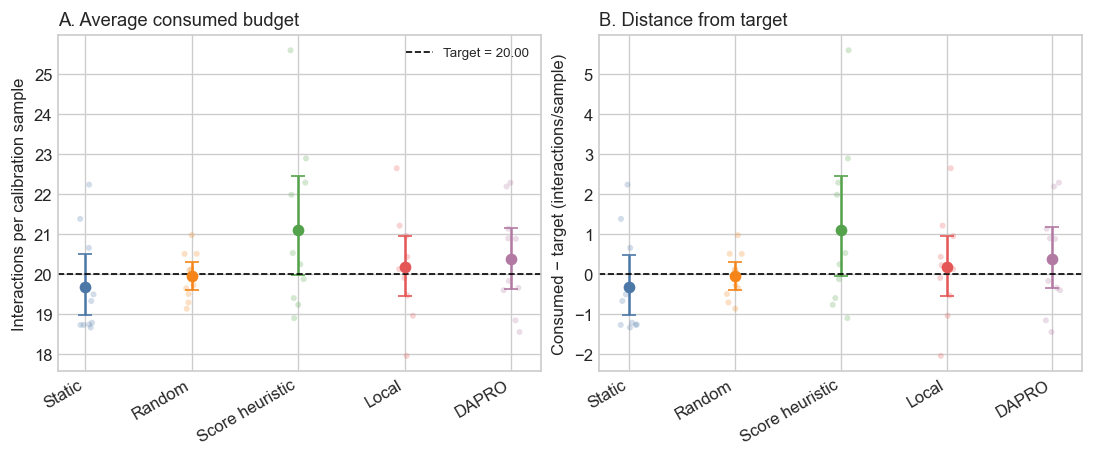

**Interpretation.** Each faint point is one split; circles and error bars are means and paired-split bootstrap 95% intervals. **RandomAdaptive** is closest on average to the configured target, consuming 19.94 interactions per calibration sample (-0.06 from target). The fraction above target is reported because a mean near the target can hide split-level overruns. This figure displays only per-sample averages, never an aggregate budget total.

In [7]:
budget_per_sample_rows = []
for method_index, method in enumerate(METHOD_ORDER):
    part = split_df.loc[split_df.method.eq(method)].sort_values("split_id")
    consumed = part["realized_total_budget_per_sample"].to_numpy(dtype=float)
    difference = consumed - nominal_total_budget
    consumed_lo, consumed_hi = bootstrap_mean_ci(
        consumed, BOOTSTRAP_SEED + 7_000 + method_index
    )
    difference_lo, difference_hi = bootstrap_mean_ci(
        difference, BOOTSTRAP_SEED + 7_100 + method_index
    )
    budget_per_sample_rows.append({
        "method": method,
        "target_budget_per_sample": nominal_total_budget,
        "mean_consumed_budget_per_sample": float(np.mean(consumed)),
        "consumed_budget_ci_lower": consumed_lo,
        "consumed_budget_ci_upper": consumed_hi,
        "mean_difference_from_target": float(np.mean(difference)),
        "difference_ci_lower": difference_lo,
        "difference_ci_upper": difference_hi,
        "fraction_splits_above_target": float((difference > 0).mean()),
        "maximum_budget_per_sample": float(np.max(consumed)),
        "n_splits": len(consumed),
    })
budget_per_sample_summary = pd.DataFrame(budget_per_sample_rows)
budget_per_sample_summary.to_csv(
    OUTPUT_DIR / "budget_per_sample_summary.csv", index=False
)

budget_per_sample_md = markdown_table(
    [
        "Method",
        "Target budget/sample",
        "Consumed budget/sample",
        "Consumed − target",
        "Splits above target",
    ],
    [
        [
            SHORT_NAMES[row.method],
            f"{row.target_budget_per_sample:.2f}",
            (
                f"{row.mean_consumed_budget_per_sample:.2f} "
                f"[{row.consumed_budget_ci_lower:.2f}, "
                f"{row.consumed_budget_ci_upper:.2f}]"
            ),
            (
                f"{row.mean_difference_from_target:+.2f} "
                f"[{row.difference_ci_lower:+.2f}, "
                f"{row.difference_ci_upper:+.2f}]"
            ),
            f"{row.fraction_splits_above_target:.0%}",
        ]
        for _, row in budget_per_sample_summary.iterrows()
    ],
)
(OUTPUT_DIR / "budget_per_sample_summary.md").write_text(
    budget_per_sample_md + "\n\n"
    "Consumed budget is the average number of interactions per original calibration "
    "sample, including Phase I and Phase II. Brackets are paired-split bootstrap "
    "95% confidence intervals for the mean.\n",
    encoding="utf-8",
)
display(Markdown(budget_per_sample_md))

fig, axes = plt.subplots(1, 2, figsize=(9.0, 3.7), constrained_layout=True)
rng = np.random.default_rng(BOOTSTRAP_SEED + 7_200)
for method_index, method in enumerate(METHOD_ORDER):
    values = split_df.loc[
        split_df.method.eq(method), "realized_total_budget_per_sample"
    ].to_numpy(dtype=float)
    jitter = rng.uniform(-0.08, 0.08, len(values))
    axes[0].scatter(
        np.full(len(values), method_index) + jitter,
        values,
        s=13,
        alpha=0.25,
        color=COLORS[method],
        edgecolor="none",
    )
    row = budget_per_sample_summary.loc[
        budget_per_sample_summary.method.eq(method)
    ].iloc[0]
    axes[0].errorbar(
        method_index,
        row.mean_consumed_budget_per_sample,
        yerr=[[
            row.mean_consumed_budget_per_sample - row.consumed_budget_ci_lower
        ], [
            row.consumed_budget_ci_upper - row.mean_consumed_budget_per_sample
        ]],
        fmt="o",
        color=COLORS[method],
        capsize=4,
        linewidth=1.5,
    )

    differences = values - nominal_total_budget
    jitter = rng.uniform(-0.08, 0.08, len(differences))
    axes[1].scatter(
        np.full(len(differences), method_index) + jitter,
        differences,
        s=13,
        alpha=0.25,
        color=COLORS[method],
        edgecolor="none",
    )
    axes[1].errorbar(
        method_index,
        row.mean_difference_from_target,
        yerr=[[
            row.mean_difference_from_target - row.difference_ci_lower
        ], [
            row.difference_ci_upper - row.mean_difference_from_target
        ]],
        fmt="o",
        color=COLORS[method],
        capsize=4,
        linewidth=1.5,
    )

axes[0].axhline(
    nominal_total_budget, color="black", linestyle="--", linewidth=1,
    label=f"Target = {nominal_total_budget:.2f}",
)
axes[0].set_title("A. Average consumed budget", loc="left")
axes[0].set_ylabel("Interactions per calibration sample")
axes[0].legend(frameon=False)
axes[1].axhline(0, color="black", linestyle="--", linewidth=1)
axes[1].set_title("B. Distance from target", loc="left")
axes[1].set_ylabel("Consumed − target (interactions/sample)")
for ax in axes:
    ax.set_xticks(range(len(METHOD_ORDER)))
    ax.set_xticklabels(
        [SHORT_NAMES[method] for method in METHOD_ORDER],
        rotation=30,
        ha="right",
    )
save_figure(fig, "figure_budget_per_sample")
plt.show()

closest_method = budget_per_sample_summary.iloc[
    budget_per_sample_summary.mean_difference_from_target.abs().argmin()
]
display(Markdown(
    f"**Interpretation.** Each faint point is one split; circles and error bars are "
    f"means and paired-split bootstrap 95% intervals. **{closest_method.method}** is "
    f"closest on average to the configured target, consuming "
    f"{closest_method.mean_consumed_budget_per_sample:.2f} interactions per calibration "
    f"sample ({closest_method.mean_difference_from_target:+.2f} from target). "
    "The fraction above target is reported because a mean near the target can hide "
    "split-level overruns. This figure displays only per-sample averages, never an "
    "aggregate budget total."
))


## 6. Paired optimization-versus-adaptivity comparisons

### Which comparator answers which ablation question?

| Comparator to DAPRO | What the comparison isolates |
|---|---|
| ScoreAdaptive-Heuristic | **Cleanest Phase-I optimization ablation:** same learned score, target budget, paired splits, and common random numbers, but no inverse-weight optimization. |
| RandomAdaptive | Whether DAPRO's score-informed optimization improves over generic stochastic dynamic censoring. This is an important downstream sanity check, but changes both score use and optimization. |
| LocallyAdaptive | Globally optimized allocation versus a local adaptive shadow-price policy. |
| Static | The full dynamic DAPRO pipeline versus non-adaptive censoring; it does not isolate Phase-I optimization alone. |

No additional baseline isolates the Phase-I optimization more cleanly than the score-adaptive heuristic. RandomAdaptive is nevertheless essential because a sophisticated proxy objective should be compared with a simple dynamic rule on the final coverage and variance outcomes.

In [8]:
metric_roles = {
    "absolute_coverage_deviation_pp": ("primary", "lower"),
    "phase2_mean_latent_terminal_weight": ("primary", "lower"),
    "phase2_p99_trimmed_mean_latent_terminal_weight": ("visualization", "lower"),
    "weighted_miscoverage_variance": ("primary", "lower"),
    "realized_total_budget_per_sample": ("budget_descriptive", "neutral"),
    "total_budget_overrun": ("budget_descriptive", "neutral"),
    "mean_lpb_size": ("secondary_descriptive", "conditional_higher"),
    "selected_tau": ("secondary_descriptive", "neutral"),
    "reconstructed_resolution_rate": ("secondary_descriptive", "higher"),
}
paired_rows = []
paired_vectors = {}
for comparison_index, (first, second) in enumerate(ALL_COMPARISONS):
    for metric_index, (metric, (role, direction)) in enumerate(metric_roles.items()):
        pivot = split_df.pivot(index="split_id", columns="method", values=metric)
        differences = (pivot[first] - pivot[second]).dropna()
        paired_vectors[(first, second, metric)] = differences
        lo, hi = bootstrap_mean_ci(
            differences,
            BOOTSTRAP_SEED + comparison_index * 100 + metric_index,
        )
        mean_difference = float(differences.mean())
        std = float(differences.std(ddof=1)) if len(differences) > 1 else 0.0
        if direction == "lower":
            win_rate = float((differences < 0).mean())
        elif direction == "higher":
            win_rate = float((differences > 0).mean())
        else:
            win_rate = math.nan
        coverage_gap_pp = float(
            100 * (
                split_df.loc[split_df.method.eq(first), "empirical_coverage"].mean()
                - split_df.loc[split_df.method.eq(second), "empirical_coverage"].mean()
            )
        )
        lpb_direction_valid = (
            metric != "mean_lpb_size" or abs(coverage_gap_pp) < 0.5
        )
        if metric == "mean_lpb_size" and lpb_direction_valid:
            win_rate = float((differences > 0).mean())
        elif metric == "mean_lpb_size":
            win_rate = math.nan
        paired_rows.append({
            "first_method": first,
            "second_method": second,
            "comparison": f"{first} - {second}",
            "metric": metric,
            "metric_role": role,
            "mean_paired_difference": mean_difference,
            "median_paired_difference": float(differences.median()),
            "bootstrap_ci_lower": lo,
            "bootstrap_ci_upper": hi,
            "fraction_first_better": win_rate,
            "fraction_first_lower": float((differences < 0).mean()),
            "standardized_paired_effect": mean_difference / std if std > 0 else math.nan,
            "wilcoxon_p_raw": paired_wilcoxon(differences),
            "wilcoxon_p_holm": math.nan,
            "n_splits": len(differences),
            "better_direction": direction,
            "mean_coverage_difference_pp": coverage_gap_pp,
            "lpb_directional_interpretation_allowed": lpb_direction_valid,
        })
paired_results = pd.DataFrame(paired_rows)
primary_mask = paired_results["metric_role"].eq("primary")
paired_results.loc[primary_mask, "wilcoxon_p_holm"] = holm_adjust(
    paired_results.loc[primary_mask, "wilcoxon_p_raw"].to_numpy()
)
paired_results.to_csv(OUTPUT_DIR / "primary_paired_comparisons.csv", index=False)

primary_display = paired_results.loc[primary_mask].copy()
primary_display["mean [95% CI]"] = primary_display.apply(
    lambda row: (
        f"{row.mean_paired_difference:.3g} "
        f"[{row.bootstrap_ci_lower:.3g}, {row.bootstrap_ci_upper:.3g}]"
    ), axis=1
)
primary_md = markdown_table(
    ["Comparison", "Metric", "Mean difference [95% CI]", "Win rate", "Raw p", "Holm p"],
    [
        [
            row.comparison,
            row.metric,
            row["mean [95% CI]"],
            f"{row.fraction_first_better:.0%}",
            f"{row.wilcoxon_p_raw:.3g}",
            f"{row.wilcoxon_p_holm:.3g}",
        ]
        for _, row in primary_display.iterrows()
    ],
)
(OUTPUT_DIR / "primary_paired_comparisons.md").write_text(primary_md + "\n")
display(Markdown(primary_md))

# Compare cross-split variances using a paired bootstrap over split IDs.
variance_comparison_metrics = {
    "empirical_coverage_pct": "empirical_coverage_variance_pp2",
    "absolute_coverage_deviation_pp": "coverage_error_variance_pp2",
    "mean_lpb_size": "mean_lpb_size_variance_across_splits",
    "weighted_miscoverage_variance": "weighted_miscoverage_variance_across_splits",
}
variance_comparison_rows = []
for comparison_index, (first, second) in enumerate(DAPRO_COMPARISONS):
    for metric_index, (source, label) in enumerate(variance_comparison_metrics.items()):
        pivot = split_df.pivot(index="split_id", columns="method", values=source)[
            [first, second]
        ].dropna()
        estimate = float(np.var(pivot[first], ddof=1) - np.var(pivot[second], ddof=1))
        lo, hi = bootstrap_paired_variance_difference(
            pivot[first].to_numpy(),
            pivot[second].to_numpy(),
            BOOTSTRAP_SEED + 5_000 + comparison_index * 20 + metric_index,
        )
        variance_comparison_rows.append({
            "first_method": first,
            "second_method": second,
            "comparison": f"{first} - {second}",
            "metric": label,
            "variance_difference": estimate,
            "bootstrap_ci_lower": lo,
            "bootstrap_ci_upper": hi,
            "n_splits": len(pivot),
        })
dapro_variance_comparisons = pd.DataFrame(variance_comparison_rows)
dapro_variance_comparisons.to_csv(
    OUTPUT_DIR / "dapro_variance_comparisons.csv", index=False
)

dapro_all_method_comparisons = paired_results[
    paired_results.first_method.eq("DAPRO")
].copy()
dapro_all_method_comparisons.to_csv(
    OUTPUT_DIR / "dapro_all_method_comparisons.csv", index=False
)

def paired_result(comparator, metric):
    return paired_results[
        paired_results.first_method.eq("DAPRO")
        & paired_results.second_method.eq(comparator)
        & paired_results.metric.eq(metric)
    ].iloc[0]

comparison_rows = []
for comparator in [second for _, second in DAPRO_COMPARISONS]:
    coverage = paired_result(comparator, "absolute_coverage_deviation_pp")
    weight = paired_result(comparator, "phase2_mean_latent_terminal_weight")
    variance = paired_result(comparator, "weighted_miscoverage_variance")
    budget = paired_result(comparator, "realized_total_budget_per_sample")
    comparison_rows.append([
        SHORT_NAMES[comparator],
        f"{coverage.mean_paired_difference:.2f} "
        f"[{coverage.bootstrap_ci_lower:.2f}, {coverage.bootstrap_ci_upper:.2f}]",
        f"{weight.mean_paired_difference:.2g}",
        f"{variance.mean_paired_difference:.2g}",
        f"{budget.mean_paired_difference:+.2f}",
        f"{coverage.fraction_first_better:.0%}",
    ])
dapro_all_comparisons_md = markdown_table(
    [
        "Comparator",
        "Δ coverage error (pp)",
        "Δ mean inverse weight",
        "Δ weighted-miscoverage variance",
        "Δ average budget/sample",
        "Coverage win rate",
    ],
    comparison_rows,
)
(OUTPUT_DIR / "dapro_all_method_comparisons.md").write_text(
    dapro_all_comparisons_md + "\n\n"
    "All deltas are DAPRO minus comparator; negative favors DAPRO for the first "
    "three metrics. Budget is descriptive.\n",
    encoding="utf-8",
)

variance_rows = []
for comparator in [second for _, second in DAPRO_COMPARISONS]:
    part = dapro_variance_comparisons[
        dapro_variance_comparisons.second_method.eq(comparator)
    ].set_index("metric")
    variance_rows.append([
        SHORT_NAMES[comparator],
        (
            f"{part.loc['empirical_coverage_variance_pp2', 'variance_difference']:.3f} "
            f"[{part.loc['empirical_coverage_variance_pp2', 'bootstrap_ci_lower']:.3f}, "
            f"{part.loc['empirical_coverage_variance_pp2', 'bootstrap_ci_upper']:.3f}]"
        ),
        (
            f"{part.loc['coverage_error_variance_pp2', 'variance_difference']:.3f} "
            f"[{part.loc['coverage_error_variance_pp2', 'bootstrap_ci_lower']:.3f}, "
            f"{part.loc['coverage_error_variance_pp2', 'bootstrap_ci_upper']:.3f}]"
        ),
        (
            f"{part.loc['mean_lpb_size_variance_across_splits', 'variance_difference']:.3f} "
            f"[{part.loc['mean_lpb_size_variance_across_splits', 'bootstrap_ci_lower']:.3f}, "
            f"{part.loc['mean_lpb_size_variance_across_splits', 'bootstrap_ci_upper']:.3f}]"
        ),
    ])
dapro_variance_comparisons_md = markdown_table(
    [
        "Comparator",
        "Δ Var coverage (pp²)",
        "Δ Var coverage error (pp²)",
        "Δ Var mean LPB",
    ],
    variance_rows,
)
(OUTPUT_DIR / "dapro_variance_comparisons.md").write_text(
    dapro_variance_comparisons_md + "\n\n"
    "All deltas are DAPRO minus comparator; negative indicates lower split-to-split variance.\n",
    encoding="utf-8",
)
display(Markdown(
    "### DAPRO against every baseline\n\n" + dapro_all_comparisons_md
    + "\n\n### Paired-bootstrap variance comparisons\n\n"
    + dapro_variance_comparisons_md
))


| Comparison | Metric | Mean difference [95% CI] | Win rate | Raw p | Holm p |
|---|---:|---:|---:|---:|---:|
| DAPRO - ScoreAdaptive-Heuristic | absolute_coverage_deviation_pp | -0.09 [-0.273, 0.107] | 70% | 0.426 | 1 |
| DAPRO - ScoreAdaptive-Heuristic | phase2_mean_latent_terminal_weight | -1.41e+56 [-3.51e+56, -1.19e+54] | 100% | 0.00195 | 0.041 |
| DAPRO - ScoreAdaptive-Heuristic | weighted_miscoverage_variance | 5.35e-06 [3.64e-06, 6.93e-06] | 10% | 0.00391 | 0.041 |
| DAPRO - RandomAdaptive | absolute_coverage_deviation_pp | -0.0367 [-0.17, 0.117] | 50% | 0.438 | 1 |
| DAPRO - RandomAdaptive | phase2_mean_latent_terminal_weight | -3.18e+03 [-4.22e+03, -2.3e+03] | 100% | 0.00195 | 0.041 |
| DAPRO - RandomAdaptive | weighted_miscoverage_variance | 1.17e-05 [9.91e-06, 1.35e-05] | 0% | 0.00195 | 0.041 |
| DAPRO - LocallyAdaptive | absolute_coverage_deviation_pp | -0.623 [-1.1, -0.143] | 70% | 0.0391 | 0.273 |
| DAPRO - LocallyAdaptive | phase2_mean_latent_terminal_weight | 1.2 [1.15, 1.25] | 0% | 0.00195 | 0.041 |
| DAPRO - LocallyAdaptive | weighted_miscoverage_variance | -0.000144 [-0.000154, -0.000134] | 100% | 0.00195 | 0.041 |
| DAPRO - Static | absolute_coverage_deviation_pp | -0.0667 [-0.57, 0.36] | 40% | 1 | 1 |
| DAPRO - Static | phase2_mean_latent_terminal_weight | 1.14 [1.08, 1.19] | 0% | 0.00195 | 0.041 |
| DAPRO - Static | weighted_miscoverage_variance | -0.000153 [-0.000162, -0.000144] | 100% | 0.00195 | 0.041 |
| ScoreAdaptive-Heuristic - RandomAdaptive | absolute_coverage_deviation_pp | 0.0533 [-0.0867, 0.183] | 10% | 0.312 | 1 |
| ScoreAdaptive-Heuristic - RandomAdaptive | phase2_mean_latent_terminal_weight | 1.41e+56 [1.14e+54, 3.51e+56] | 0% | 0.00195 | 0.041 |
| ScoreAdaptive-Heuristic - RandomAdaptive | weighted_miscoverage_variance | 6.33e-06 [5.07e-06, 7.71e-06] | 0% | 0.00195 | 0.041 |
| RandomAdaptive - Static | absolute_coverage_deviation_pp | -0.03 [-0.533, 0.423] | 40% | 1 | 1 |
| RandomAdaptive - Static | phase2_mean_latent_terminal_weight | 3.19e+03 [2.3e+03, 4.24e+03] | 0% | 0.00195 | 0.041 |
| RandomAdaptive - Static | weighted_miscoverage_variance | -0.000165 [-0.000175, -0.000154] | 100% | 0.00195 | 0.041 |
| LocallyAdaptive - Static | absolute_coverage_deviation_pp | 0.557 [-0.187, 1.24] | 30% | 0.203 | 1 |
| LocallyAdaptive - Static | phase2_mean_latent_terminal_weight | -0.0612 [-0.0752, -0.0476] | 100% | 0.00195 | 0.041 |
| LocallyAdaptive - Static | weighted_miscoverage_variance | -9.26e-06 [-1.38e-05, -4.56e-06] | 90% | 0.00977 | 0.0781 |

### DAPRO against every baseline

| Comparator | Δ coverage error (pp) | Δ mean inverse weight | Δ weighted-miscoverage variance | Δ average budget/sample | Coverage win rate |
|---|---:|---:|---:|---:|---:|
| Score heuristic | -0.09 [-0.27, 0.11] | -1.4e+56 | 5.3e-06 | -0.71 | 70% |
| Random | -0.04 [-0.17, 0.12] | -3.2e+03 | 1.2e-05 | +0.44 | 50% |
| Local | -0.62 [-1.10, -0.14] | 1.2 | -0.00014 | +0.20 | 70% |
| Static | -0.07 [-0.57, 0.36] | 1.1 | -0.00015 | +0.71 | 40% |

### Paired-bootstrap variance comparisons

| Comparator | Δ Var coverage (pp²) | Δ Var coverage error (pp²) | Δ Var mean LPB |
|---|---:|---:|---:|
| Score heuristic | -0.369 [-0.961, 0.138] | -0.241 [-0.475, -0.011] | -0.029 [-0.144, 0.092] |
| Random | -0.045 [-0.335, 0.261] | -0.034 [-0.101, 0.056] | 0.021 [-0.063, 0.120] |
| Local | -1.907 [-3.350, -0.337] | -0.496 [-0.858, -0.047] | -0.484 [-0.802, -0.141] |
| Static | 0.189 [-0.357, 0.696] | -0.028 [-0.315, 0.284] | 0.016 [-0.131, 0.147] |

### 6.1 Overall paired-difference figure

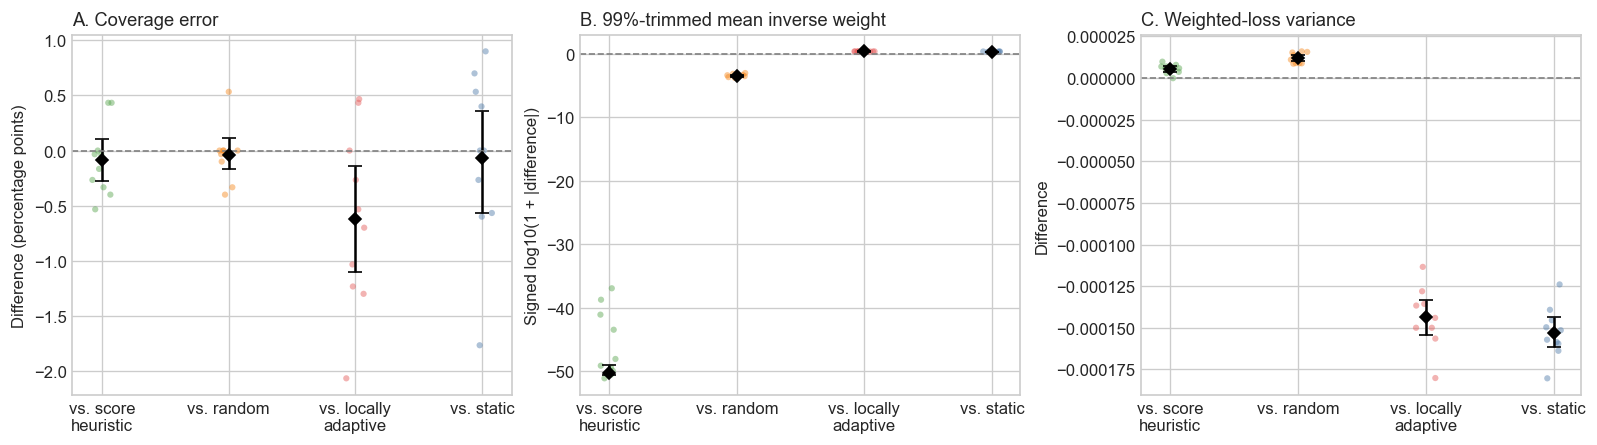

**Interpretation.** Each point is a paired split-level difference; negative values favor DAPRO. The mean-weight panel uses a signed log transform solely to show comparisons whose raw magnitudes differ by many orders; reported estimates and intervals remain on the raw scale. The comparisons answer whether inverse-weight optimization adds value beyond two adaptive and static alternatives.

- **Coverage error vs. ScoreAdaptive-Heuristic:** mean paired difference -0.09 (95% CI -0.273 to 0.107); DAPRO win rate 70%. This numerically favors DAPRO, but the evidence is inconclusive.
- **99%-trimmed mean inverse weight vs. ScoreAdaptive-Heuristic:** mean paired difference -1.83e+50 (95% CI -4.59e+50 to -8.96e+48); DAPRO win rate 100%. This numerically favors DAPRO, but the evidence is inconclusive.
- **Weighted-loss variance vs. ScoreAdaptive-Heuristic:** mean paired difference 5.35e-06 (95% CI 3.64e-06 to 6.93e-06); DAPRO win rate 10%. This does not favor DAPRO.
- **Coverage error vs. RandomAdaptive:** mean paired difference -0.0367 (95% CI -0.17 to 0.117); DAPRO win rate 50%. This numerically favors DAPRO, but the evidence is inconclusive.
- **99%-trimmed mean inverse weight vs. RandomAdaptive:** mean paired difference -3.18e+03 (95% CI -4.23e+03 to -2.28e+03); DAPRO win rate 100%. This numerically favors DAPRO, but the evidence is inconclusive.
- **Weighted-loss variance vs. RandomAdaptive:** mean paired difference 1.17e-05 (95% CI 9.91e-06 to 1.35e-05); DAPRO win rate 0%. This does not favor DAPRO.
- **Coverage error vs. LocallyAdaptive:** mean paired difference -0.623 (95% CI -1.1 to -0.143); DAPRO win rate 70%. This numerically favors DAPRO, but the evidence is inconclusive.
- **99%-trimmed mean inverse weight vs. LocallyAdaptive:** mean paired difference 1.17 (95% CI 1.11 to 1.22); DAPRO win rate 0%. This does not favor DAPRO.
- **Weighted-loss variance vs. LocallyAdaptive:** mean paired difference -0.000144 (95% CI -0.000154 to -0.000134); DAPRO win rate 100%. This favors DAPRO and passes the Holm-adjusted test.
- **Coverage error vs. Static:** mean paired difference -0.0667 (95% CI -0.57 to 0.36); DAPRO win rate 40%. This numerically favors DAPRO, but the evidence is inconclusive.
- **99%-trimmed mean inverse weight vs. Static:** mean paired difference 1.1 (95% CI 1.03 to 1.15); DAPRO win rate 0%. This does not favor DAPRO.
- **Weighted-loss variance vs. Static:** mean paired difference -0.000153 (95% CI -0.000162 to -0.000144); DAPRO win rate 100%. This favors DAPRO and passes the Holm-adjusted test.

These splits reuse one underlying dataset and are not independent new datasets.

In [9]:
figure_metrics = [
    ("absolute_coverage_deviation_pp", "A. Coverage error", "Difference (percentage points)"),
    ("phase2_p99_trimmed_mean_latent_terminal_weight", "B. 99%-trimmed mean inverse weight", "Difference"),
    ("weighted_miscoverage_variance", "C. Weighted-loss variance", "Difference"),
]
comparator_pairs = DAPRO_COMPARISONS
fig, axes = plt.subplots(1, 3, figsize=(13.2, 3.6), constrained_layout=True)
rng = np.random.default_rng(BOOTSTRAP_SEED)
signed_log10 = lambda values: np.sign(values) * np.log10(1 + np.abs(values))
for metric_index, (ax, (metric, title, ylabel)) in enumerate(zip(axes, figure_metrics)):
    for x, (first, second) in enumerate(comparator_pairs):
        values = paired_vectors[(first, second, metric)].to_numpy()
        plotted_values = signed_log10(values) if "terminal_weight" in metric else values
        jitter = rng.uniform(-0.08, 0.08, len(values))
        ax.scatter(
            np.full(len(values), x) + jitter, plotted_values,
            s=14, alpha=0.45, color=COLORS[second], edgecolor="none",
        )
        row = paired_results[
            paired_results.first_method.eq(first)
            & paired_results.second_method.eq(second)
            & paired_results.metric.eq(metric)
        ].iloc[0]
        plotted_mean = (
            signed_log10(row.mean_paired_difference)
            if "terminal_weight" in metric
            else row.mean_paired_difference
        )
        plotted_low = (
            signed_log10(row.bootstrap_ci_lower)
            if "terminal_weight" in metric
            else row.bootstrap_ci_lower
        )
        plotted_high = (
            signed_log10(row.bootstrap_ci_upper)
            if "terminal_weight" in metric
            else row.bootstrap_ci_upper
        )
        ax.errorbar(
            x, plotted_mean,
            yerr=[[plotted_mean - plotted_low], [plotted_high - plotted_mean]],
            fmt="D", color="black", capsize=4, markersize=5, linewidth=1.5,
        )
    ax.axhline(0, color="gray", linestyle="--", linewidth=1)
    ax.set_xticks(range(len(comparator_pairs)))
    ax.set_xticklabels([
        "vs. score\nheuristic",
        "vs. random",
        "vs. locally\nadaptive",
        "vs. static",
    ])
    ax.set_title(title, loc="left")
    ax.set_ylabel(ylabel)
    if "terminal_weight" in metric:
        ax.set_ylabel("Signed log10(1 + |difference|)")
save_figure(fig, "figure_overall_paired_differences")
plt.show()

interpretation_lines = []
for first, second in comparator_pairs:
    for metric, label, _ in figure_metrics:
        row = paired_results[
            paired_results.first_method.eq(first)
            & paired_results.second_method.eq(second)
            & paired_results.metric.eq(metric)
        ].iloc[0]
        favorable = row.mean_paired_difference < 0
        excludes_zero = row.bootstrap_ci_upper < 0 or row.bootstrap_ci_lower > 0
        adjusted = row.wilcoxon_p_holm
        if favorable and row.bootstrap_ci_upper < 0 and adjusted < TEST_ALPHA:
            verdict = "favors DAPRO and passes the Holm-adjusted test"
        elif favorable:
            verdict = "numerically favors DAPRO, but the evidence is inconclusive"
        else:
            verdict = "does not favor DAPRO"
        interpretation_lines.append(
            f"- **{label.split('. ', 1)[-1]} vs. {second}:** "
            f"mean paired difference {row.mean_paired_difference:.3g} "
            f"(95% CI {row.bootstrap_ci_lower:.3g} to {row.bootstrap_ci_upper:.3g}); "
            f"DAPRO win rate {row.fraction_first_better:.0%}. This {verdict}."
        )
display(Markdown(
    "**Interpretation.** Each point is a paired split-level difference; negative values favor "
    "DAPRO. The mean-weight panel uses a signed log transform solely to show comparisons whose "
    "raw magnitudes differ by many orders; reported estimates and intervals remain on the raw "
    "scale. The comparisons answer whether inverse-weight optimization adds value beyond two "
    "adaptive and static alternatives.\n\n" + "\n".join(interpretation_lines)
    + "\n\nThese splits reuse one underlying dataset and are not independent new datasets."
))

### 6.2 All-method summary figure

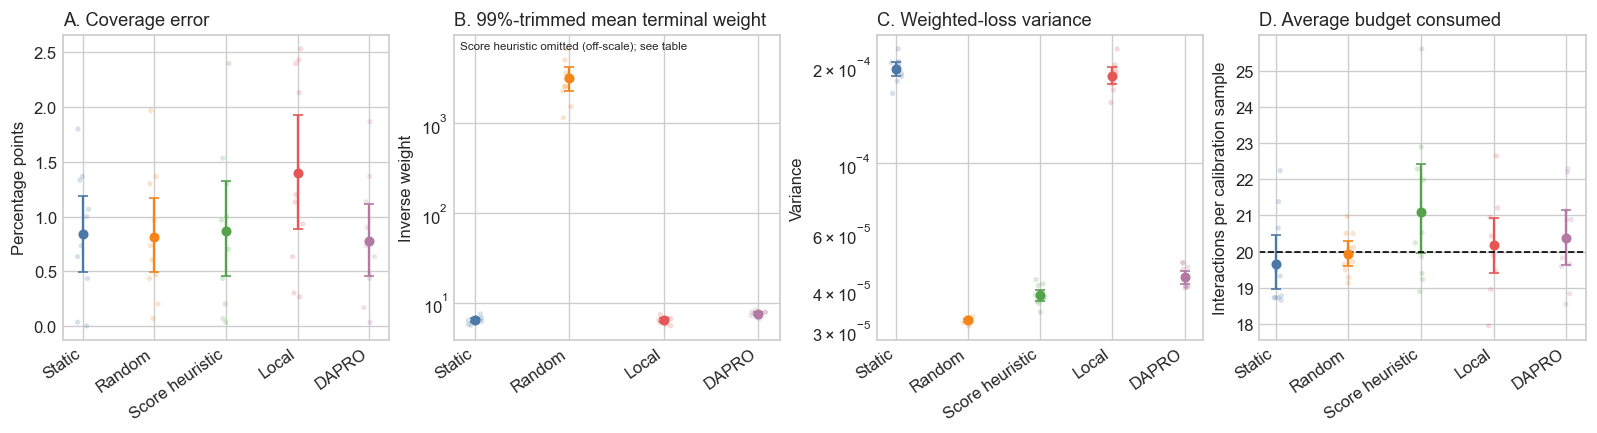

**Interpretation.** Means and bootstrap intervals summarize all five methods; faint points show individual splits. The budget panel is average consumed interactions per original calibration sample, and the dashed line is the configured per-sample target. This broader comparison places the optimization ablation in context: **DAPRO** has the lowest mean coverage error, **LocallyAdaptive** the lowest mean latent weight, and **RandomAdaptive** the lowest mean weighted-loss variance. DAPRO averages 0.77 pp coverage error, 7.59 mean latent weight, and 20.38 interactions/calibration sample; 50% of its splits exceed the nominal target. These marginal summaries do not replace the paired comparisons or establish global optimality. LPB size (reported in the CSV) is only meaningful at comparable coverage, and latent terminal weight is an offline diagnostic that need not be available online.

In [10]:
method_figure_specs = [
    ("absolute_coverage_deviation_pp", "A. Coverage error", "Percentage points"),
    ("phase2_p99_trimmed_mean_latent_terminal_weight", "B. 99%-trimmed mean terminal weight", "Inverse weight"),
    ("weighted_miscoverage_variance", "C. Weighted-loss variance", "Variance"),
    (
        "realized_total_budget_per_sample",
        "D. Average budget consumed",
        "Interactions per calibration sample",
    ),
]
fig, axes = plt.subplots(1, 4, figsize=(13.2, 3.5), constrained_layout=True)
rng = np.random.default_rng(BOOTSTRAP_SEED + 400)
for panel_index, (ax, (metric, title, ylabel)) in enumerate(zip(axes, method_figure_specs)):
    panel_methods = (
        [method for method in METHOD_ORDER if method != "ScoreAdaptive-Heuristic"]
        if "terminal_weight" in metric else METHOD_ORDER
    )
    for x, method in enumerate(panel_methods):
        values = split_df.loc[split_df.method.eq(method), metric].dropna().to_numpy()
        jitter = rng.uniform(-0.08, 0.08, len(values))
        ax.scatter(
            np.full(len(values), x) + jitter, values,
            s=10, alpha=0.22, color=COLORS[method], edgecolor="none",
        )
        lo, hi = bootstrap_mean_ci(values, BOOTSTRAP_SEED + 500 + panel_index * 10 + x)
        mean = float(np.mean(values))
        ax.errorbar(
            x, mean, yerr=[[mean - lo], [hi - mean]], fmt="o",
            color=COLORS[method], capsize=3, markersize=5, linewidth=1.4,
        )
    ax.set_xticks(range(len(panel_methods)))
    ax.set_xticklabels([SHORT_NAMES[m] for m in panel_methods], rotation=35, ha="right")
    ax.set_title(title, loc="left")
    ax.set_ylabel(ylabel)
    if "terminal_weight" in metric:
        ax.set_yscale("log")
        ax.text(
            0.02, 0.98, "Score heuristic omitted (off-scale); see table",
            transform=ax.transAxes, va="top", fontsize=7,
        )
    if metric == "weighted_miscoverage_variance":
        ax.set_yscale("log")
    if "budget" in metric:
        target = nominal_total_budget if total_budget_available else split_df.target_budget_per_sample.mean()
        ax.axhline(target, color="black", linestyle="--", linewidth=1)
save_figure(fig, "figure_method_summary")
plt.show()
summary_lookup = overall_summary.set_index("method")
best_coverage_method = summary_lookup["coverage_error_pp_mean"].idxmin()
best_weight_method = summary_lookup["mean_latent_weight_mean"].idxmin()
best_variance_method = summary_lookup["weighted_miscoverage_variance_mean"].idxmin()
dapro_summary = summary_lookup.loc["DAPRO"]
display(Markdown(
    "**Interpretation.** Means and bootstrap intervals summarize all five methods; faint points "
    "show individual splits. The budget panel is average consumed interactions per original "
    "calibration sample, and the dashed line is the configured per-sample target. This broader comparison places the optimization ablation in context: "
    f"**{best_coverage_method}** has the lowest mean coverage error, **{best_weight_method}** "
    f"the lowest mean latent weight, and **{best_variance_method}** the lowest mean weighted-loss "
    f"variance. DAPRO averages {dapro_summary.coverage_error_pp_mean:.2f} pp coverage error, "
    f"{dapro_summary.mean_latent_weight_mean:.3g} mean latent weight, and "
    f"{dapro_summary.total_budget_per_sample_mean:.2f} interactions/calibration sample; "
    f"{dapro_summary.fraction_total_budget_exceeded:.0%} of its splits exceed the nominal target. "
    "These marginal summaries do not replace the paired comparisons or establish global "
    "optimality. LPB size (reported in the CSV) is only meaningful at comparable coverage, and "
    "latent terminal weight is an offline diagnostic that need not be available online."
))

### 6.3 Does the Phase-I proxy align with downstream outcomes?

This diagnostic asks whether split-level improvements in DAPRO's log mean inverse weight move together with improvements in the saved downstream metrics. A proxy can be useful for controlling extreme weights even when it is not perfectly rank-aligned with coverage error or the weighted-miscoverage variance after global calibration.

In [11]:
alignment_rows = []
for comparator_index, (_, comparator) in enumerate(DAPRO_COMPARISONS):
    pivot_weight = split_df.pivot(
        index="split_id", columns="method",
        values="phase2_mean_latent_terminal_weight",
    )
    delta_log_weight = np.log(pivot_weight["DAPRO"]) - np.log(pivot_weight[comparator])
    for downstream_metric, label in [
        ("absolute_coverage_deviation_pp", "coverage_error"),
        ("weighted_miscoverage_variance", "weighted_miscoverage_variance"),
    ]:
        pivot_downstream = split_df.pivot(
            index="split_id", columns="method", values=downstream_metric
        )
        delta_downstream = pivot_downstream["DAPRO"] - pivot_downstream[comparator]
        aligned_values = pd.concat(
            [delta_log_weight.rename("delta_log_weight"),
             delta_downstream.rename("delta_downstream")],
            axis=1,
        ).dropna()
        rho, p_value = spearmanr(
            aligned_values["delta_log_weight"],
            aligned_values["delta_downstream"],
        )
        alignment_rows.append({
            "comparator": comparator,
            "downstream_metric": label,
            "spearman_rho": float(rho),
            "spearman_p_value": float(p_value),
            "fraction_proxy_favors_dapro": float(
                (aligned_values.delta_log_weight < 0).mean()
            ),
            "fraction_downstream_favors_dapro": float(
                (aligned_values.delta_downstream < 0).mean()
            ),
            "fraction_both_favor_dapro": float(
                (
                    (aligned_values.delta_log_weight < 0)
                    & (aligned_values.delta_downstream < 0)
                ).mean()
            ),
            "fraction_proxy_favors_but_downstream_worsens": float(
                (
                    (aligned_values.delta_log_weight < 0)
                    & (aligned_values.delta_downstream > 0)
                ).mean()
            ),
            "n_splits": len(aligned_values),
        })
proxy_downstream_alignment = pd.DataFrame(alignment_rows)
proxy_downstream_alignment.to_csv(
    OUTPUT_DIR / "proxy_downstream_alignment.csv", index=False
)
display(
    proxy_downstream_alignment.set_index(
        ["comparator", "downstream_metric"]
    ).style.format({
        "spearman_rho": "{:.2f}",
        "spearman_p_value": "{:.3g}",
        "fraction_proxy_favors_dapro": "{:.0%}",
        "fraction_downstream_favors_dapro": "{:.0%}",
        "fraction_both_favor_dapro": "{:.0%}",
        "fraction_proxy_favors_but_downstream_worsens": "{:.0%}",
    })
)

random_coverage = paired_result("RandomAdaptive", "absolute_coverage_deviation_pp")
random_weight = paired_result("RandomAdaptive", "phase2_mean_latent_terminal_weight")
random_weighted_variance = paired_result(
    "RandomAdaptive", "weighted_miscoverage_variance"
)
random_variability = dapro_variance_comparisons[
    dapro_variance_comparisons.second_method.eq("RandomAdaptive")
].set_index("metric")
display(Markdown(
    "**RandomAdaptive check.** DAPRO minus RandomAdaptive has "
    f"{random_coverage.mean_paired_difference:+.2f} pp mean coverage error "
    f"(95% CI {random_coverage.bootstrap_ci_lower:.2f} to "
    f"{random_coverage.bootstrap_ci_upper:.2f}; DAPRO wins "
    f"{random_coverage.fraction_first_better:.0%} of splits), "
    f"{random_weight.mean_paired_difference:.3g} mean inverse weight difference, and "
    f"{random_weighted_variance.mean_paired_difference:+.3g} weighted-miscoverage "
    "variance difference. The DAPRO-minus-random difference in across-split variance "
    f"of mean LPB size is "
    f"{random_variability.loc['mean_lpb_size_variance_across_splits', 'variance_difference']:+.3f}. "
    "Thus inverse-weight improvement should not be presented as downstream dominance: "
    "on these saved splits, RandomAdaptive remains competitive or better on coverage "
    "and calibrated-variance diagnostics. This is evidence of proxy/downstream mismatch, "
    "not a reason to select a favorable metric after seeing the result."
))


**RandomAdaptive check.** DAPRO minus RandomAdaptive has -0.04 pp mean coverage error (95% CI -0.17 to 0.12; DAPRO wins 50% of splits), -3.18e+03 mean inverse weight difference, and +1.17e-05 weighted-miscoverage variance difference. The DAPRO-minus-random difference in across-split variance of mean LPB size is +0.021. Thus inverse-weight improvement should not be presented as downstream dominance: on these saved splits, RandomAdaptive remains competitive or better on coverage and calibrated-variance diagnostics. This is evidence of proxy/downstream mismatch, not a reason to select a favorable metric after seeing the result.

## 7. Stratified gain decomposition

In [12]:
sample_df["difficulty_ratio"] = (
    np.minimum(sample_df["T_i"], sample_df["q_prior_i"])
    / sample_df["q_prior_i"].replace(0, np.nan)
)
difficulty_order = ["Q1", "Q2", "Q3", "Q4"]
score_order = ["Q1", "Q2", "Q3", "Q4"]
difficulty_ranges = sample_df.groupby("difficulty_stratum", observed=True)["difficulty_ratio"].agg(
    ["min", "mean", "max"]
).reindex(difficulty_order)
assert np.all(np.diff(difficulty_ranges["mean"]) > 0)
display(difficulty_ranges.style.format("{:.3f}"))

# Recompute method/stratum summaries from sample-level data.
stratified_method_rows = []
for stratification, column, labels in [
    ("event_time_difficulty", "difficulty_stratum", difficulty_order),
    ("initial_score_quartile", "initial_score_quartile", score_order),
]:
    work = sample_df.dropna(subset=[column]).copy()
    totals = work.groupby(["split_id", "method"], observed=True)["latent_terminal_weight"].transform("sum")
    work["weight_mass_share_row"] = work["latent_terminal_weight"] / totals
    grouped = work.groupby(["split_id", "method", column], observed=True)
    aggregate = grouped.agg(
        sample_count=("sample_id", "size"),
        average_realized_cost=("realized_cost", "mean"),
        resolved_for_calibration_rate=("resolved_for_calibration", "mean"),
        event_observation_rate=("event_observed_indicator", "mean"),
        mean_latent_terminal_weight=("latent_terminal_weight", "mean"),
        median_latent_terminal_weight=("latent_terminal_weight", "median"),
        p90_latent_terminal_weight=("latent_terminal_weight", lambda x: x.quantile(0.90)),
        mean_log_latent_terminal_weight=("log_latent_terminal_weight", "mean"),
        variance_log_latent_terminal_weight=("log_latent_terminal_weight", "var"),
        variance_latent_terminal_weight=("latent_terminal_weight", "var"),
        variance_realized_cost=("realized_cost", "var"),
        resolution_bernoulli_variance=("resolved_for_calibration", "var"),
        total_latent_weight_mass=("latent_terminal_weight", "sum"),
        weight_mass_share=("weight_mass_share_row", "sum"),
    ).reset_index().rename(columns={column: "stratum"})
    aggregate["stratification"] = stratification
    stratified_method_rows.append(aggregate)
stratified_method = pd.concat(stratified_method_rows, ignore_index=True)

index_columns = ["split_id", "sample_id"]
aligned = sample_df.pivot(
    index=index_columns, columns="method",
    values=[
        "log_latent_terminal_weight", "latent_terminal_weight",
        "resolved_for_calibration", "realized_cost",
    ],
)
descriptors = (
    sample_df.drop_duplicates(index_columns)
    .set_index(index_columns)[["difficulty_stratum", "initial_score_quartile"]]
)
stratified_gain_rows = []
split_stratum_vectors = {}
strat_comparisons = DAPRO_COMPARISONS
for comparison_index, (first, second) in enumerate(strat_comparisons):
    metric_definitions = [
        ("log_latent_terminal_weight", "mean_log_terminal_weight_difference", 1.0),
        ("resolved_for_calibration", "resolution_rate_difference", 1.0),
        ("realized_cost", "realized_cost_difference", 1.0),
        ("latent_terminal_weight", "latent_weight_reduction", -1.0),
    ]
    for stratification, column, labels in [
        ("event_time_difficulty", "difficulty_stratum", difficulty_order),
        ("initial_score_quartile", "initial_score_quartile", score_order),
    ]:
        for metric_index, (source_metric, output_metric, sign) in enumerate(metric_definitions):
            differences = sign * (
                aligned[(source_metric, first)] - aligned[(source_metric, second)]
            )
            frame = differences.rename("difference").to_frame().join(descriptors[column])
            split_values = frame.groupby(["split_id", column], observed=True)["difference"].mean()
            split_stratum_vectors[(first, second, stratification, output_metric)] = split_values
            for stratum_index, stratum in enumerate(labels):
                values = split_values.xs(stratum, level=column).to_numpy()
                lo, hi = bootstrap_mean_ci(
                    values,
                    BOOTSTRAP_SEED + 1_000 + comparison_index * 200
                    + metric_index * 20 + stratum_index,
                )
                stratified_gain_rows.append({
                    "first_method": first,
                    "second_method": second,
                    "comparison": f"{first} - {second}",
                    "stratification": stratification,
                    "stratum": stratum,
                    "metric": output_metric,
                    "mean": float(np.mean(values)),
                    "bootstrap_ci_lower": lo,
                    "bootstrap_ci_upper": hi,
                    "n_splits": len(values),
                })

# Add method-level stratum variance differences. These are differences of
# within-stratum sample variances, paired by split.
for comparison_index, (first, second) in enumerate(strat_comparisons):
    for stratification in ["event_time_difficulty", "initial_score_quartile"]:
        part = stratified_method[
            stratified_method.stratification.eq(stratification)
        ]
        for metric_index, (source_metric, output_metric) in enumerate([
            ("variance_log_latent_terminal_weight", "log_weight_variance_difference"),
            ("variance_realized_cost", "realized_cost_variance_difference"),
            ("resolution_bernoulli_variance", "resolution_variance_difference"),
        ]):
            pivot = part.pivot(
                index=["split_id", "stratum"], columns="method", values=source_metric
            )
            difference = (pivot[first] - pivot[second]).rename("difference")
            split_stratum_vectors[
                (first, second, stratification, output_metric)
            ] = difference
            for stratum_index, stratum in enumerate(["Q1", "Q2", "Q3", "Q4"]):
                values = difference.xs(stratum, level="stratum").dropna().to_numpy()
                lo, hi = bootstrap_mean_ci(
                    values,
                    BOOTSTRAP_SEED + 6_000 + comparison_index * 100
                    + metric_index * 10 + stratum_index,
                )
                stratified_gain_rows.append({
                    "first_method": first,
                    "second_method": second,
                    "comparison": f"{first} - {second}",
                    "stratification": stratification,
                    "stratum": stratum,
                    "metric": output_metric,
                    "mean": float(np.mean(values)),
                    "bootstrap_ci_lower": lo,
                    "bootstrap_ci_upper": hi,
                    "n_splits": len(values),
                })

# Per-split reduction shares; splits with nonpositive total reduction retain raw totals and NaN shares.
reduction_share_rows = []
weight_pivot = sample_df.pivot(
    index=index_columns, columns="method", values="latent_terminal_weight"
)
for comparison_index, comparator in enumerate([second for _, second in DAPRO_COMPARISONS]):
    reduction = (weight_pivot[comparator] - weight_pivot["DAPRO"]).rename("reduction")
    frame = reduction.to_frame().join(descriptors)
    for stratification, column, labels in [
        ("event_time_difficulty", "difficulty_stratum", difficulty_order),
        ("initial_score_quartile", "initial_score_quartile", score_order),
    ]:
        by_stratum = frame.groupby(["split_id", column], observed=True)["reduction"].sum()
        totals = frame.groupby("split_id")["reduction"].sum()
        for (split_id, stratum), raw_reduction in by_stratum.items():
            total = float(totals.loc[split_id])
            reduction_share_rows.append({
                "split_id": int(split_id),
                "comparison": f"DAPRO vs {comparator}",
                "comparator": comparator,
                "stratification": stratification,
                "stratum": stratum,
                "raw_weight_reduction": float(raw_reduction),
                "total_weight_reduction": total,
                "weight_reduction_share": float(raw_reduction / total) if total > 0 else math.nan,
            })
reduction_shares = pd.DataFrame(reduction_share_rows)
nonpositive_reduction_counts = (
    reduction_shares[["split_id", "comparator", "total_weight_reduction"]]
    .drop_duplicates().groupby("comparator")["total_weight_reduction"]
    .apply(lambda values: int((values <= 0).sum())).to_dict()
)

stratified_gain_summary = pd.DataFrame(stratified_gain_rows)
share_summary_rows = []
for keys, group in reduction_shares.groupby(
    ["comparison", "comparator", "stratification", "stratum"], observed=True
):
    values = group["weight_reduction_share"].dropna().to_numpy()
    lo, hi = bootstrap_mean_ci(
        values, BOOTSTRAP_SEED + 2_000 + len(share_summary_rows)
    )
    share_summary_rows.append({
        "first_method": "DAPRO",
        "second_method": keys[1],
        "comparison": keys[0],
        "stratification": keys[2],
        "stratum": keys[3],
        "metric": "weight_reduction_share",
        "mean": float(np.mean(values)) if len(values) else math.nan,
        "bootstrap_ci_lower": lo,
        "bootstrap_ci_upper": hi,
        "n_splits": len(values),
    })
stratified_gain_summary = pd.concat(
    [stratified_gain_summary, pd.DataFrame(share_summary_rows)], ignore_index=True
)
stratified_gain_summary.to_csv(OUTPUT_DIR / "stratified_gain_summary.csv", index=False)
stratified_method.to_csv(OUTPUT_DIR / "stratified_method_summary.csv", index=False)

difficulty_variability = (
    stratified_method[
        stratified_method.stratification.eq("event_time_difficulty")
    ].groupby(["method", "stratum"], observed=True)[[
        "mean_log_latent_terminal_weight",
        "variance_log_latent_terminal_weight",
        "average_realized_cost",
        "variance_realized_cost",
        "resolved_for_calibration_rate",
        "event_observation_rate",
        "resolution_bernoulli_variance",
    ]].mean().reset_index()
)
difficulty_variability["method"] = pd.Categorical(
    difficulty_variability["method"], categories=METHOD_ORDER, ordered=True
)
difficulty_variability["stratum"] = pd.Categorical(
    difficulty_variability["stratum"], categories=difficulty_order, ordered=True
)
difficulty_variability = difficulty_variability.sort_values(
    ["method", "stratum"]
).reset_index(drop=True)
difficulty_variability.to_csv(
    OUTPUT_DIR / "stratified_variability_summary.csv", index=False
)
stratified_variance_md = markdown_table(
    [
        "Method", "Difficulty", "Mean log latent inverse weight", "Var log latent inverse weight",
        "Event-time resolution", "Prior-or-event resolution", "Bernoulli var(resolution)", "Mean cost", "Var cost",
    ],
    [
        [
            SHORT_NAMES[row.method],
            row.stratum,
            f"{row.mean_log_latent_terminal_weight:.2f}",
            f"{row.variance_log_latent_terminal_weight:.2f}",
            f"{row.event_observation_rate:.1%}",
            f"{row.resolved_for_calibration_rate:.1%}",
            f"{row.resolution_bernoulli_variance:.3f}",
            f"{row.average_realized_cost:.2f}",
            f"{row.variance_realized_cost:.2f}",
        ]
        for _, row in difficulty_variability.iterrows()
    ],
)
(OUTPUT_DIR / "stratified_variability_summary.md").write_text(
    stratified_variance_md + "\n\n"
    "Event-time resolution means the event itself was successfully observed; "
    "prior-or-event resolution also counts reaching q_prior. "
    "These are calibration-stratum diagnostics, not stratum-specific test coverage.\n",
    encoding="utf-8",
)
display(Markdown(
    "### Variance within true event-time strata\n\n"
    "Q1 contains earlier events and Q4 contains late/horizon-limited trajectories. "
    "Resolution variance is the Bernoulli sample variance of the reconstructed "
    "resolution indicator. Coverage error is not available by calibration stratum.\n\n"
    + stratified_variance_md
))

largest_difficulty = (
    stratified_gain_summary[
        stratified_gain_summary.second_method.eq("ScoreAdaptive-Heuristic")
        & stratified_gain_summary.stratification.eq("event_time_difficulty")
        & stratified_gain_summary.metric.eq("latent_weight_reduction")
    ].sort_values("mean", ascending=False).iloc[0]["stratum"]
)
largest_score = (
    stratified_gain_summary[
        stratified_gain_summary.second_method.eq("ScoreAdaptive-Heuristic")
        & stratified_gain_summary.stratification.eq("initial_score_quartile")
        & stratified_gain_summary.metric.eq("latent_weight_reduction")
    ].sort_values("mean", ascending=False).iloc[0]["stratum"]
)
print("Largest DAPRO-vs-heuristic mean weight reduction:")
print(f"  difficulty stratum: {largest_difficulty}")
print(f"  score stratum: {largest_score}")
print(f"Splits with nonpositive total reduction: {nonpositive_reduction_counts}")

,min,mean,max
difficulty_stratum,,,
Q1,0.005,0.069,0.250
Q2,0.252,0.364,0.500
Q3,0.503,0.619,0.750
Q4,0.752,0.993,1.000


### Variance within true event-time strata

Q1 contains earlier events and Q4 contains late/horizon-limited trajectories. Resolution variance is the Bernoulli sample variance of the reconstructed resolution indicator. Coverage error is not available by calibration stratum.

| Method | Difficulty | Mean log latent inverse weight | Var log latent inverse weight | Event-time resolution | Prior-or-event resolution | Bernoulli var(resolution) | Mean cost | Var cost |
|---|---:|---:|---:|---:|---:|---:|---:|---:|
| Static | Q1 | 1.84 | 0.01 | 16.3% | 16.3% | 0.137 | 1.86 | 38.75 |
| Static | Q2 | 1.84 | 0.01 | 16.4% | 16.4% | 0.137 | 9.88 | 549.57 |
| Static | Q3 | 1.85 | 0.01 | 15.2% | 15.2% | 0.129 | 15.61 | 1456.04 |
| Static | Q4 | 1.87 | 0.01 | 0.8% | 15.1% | 0.128 | 25.63 | 3831.39 |
| Random | Q1 | 0.52 | 0.25 | 65.6% | 65.6% | 0.225 | 7.29 | 59.79 |
| Random | Q2 | 2.74 | 0.59 | 7.8% | 7.8% | 0.072 | 19.72 | 291.17 |
| Random | Q3 | 4.75 | 1.11 | 1.6% | 1.6% | 0.015 | 21.58 | 434.01 |
| Random | Q4 | 7.87 | 1.92 | 0.0% | 0.1% | 0.001 | 21.59 | 480.74 |
| Score heuristic | Q1 | 1.16 | 5.43 | 61.5% | 61.5% | 0.236 | 6.55 | 60.28 |
| Score heuristic | Q2 | 5.63 | 61.77 | 27.5% | 27.5% | 0.200 | 21.72 | 453.48 |
| Score heuristic | Q3 | 11.47 | 258.99 | 14.7% | 14.7% | 0.125 | 26.54 | 1007.53 |
| Score heuristic | Q4 | 26.48 | 944.75 | 0.6% | 5.8% | 0.054 | 23.48 | 1445.61 |
| Local | Q1 | 1.81 | 0.01 | 16.4% | 16.4% | 0.137 | 1.85 | 36.72 |
| Local | Q2 | 1.82 | 0.01 | 14.9% | 14.9% | 0.127 | 8.67 | 466.53 |
| Local | Q3 | 1.84 | 0.02 | 16.0% | 16.0% | 0.134 | 15.90 | 1398.85 |
| Local | Q4 | 1.87 | 0.01 | 0.8% | 15.7% | 0.132 | 26.67 | 3959.90 |
| DAPRO | Q1 | 1.12 | 0.39 | 38.4% | 38.4% | 0.236 | 3.98 | 35.44 |
| DAPRO | Q2 | 2.02 | 0.01 | 14.0% | 14.0% | 0.121 | 12.34 | 421.27 |
| DAPRO | Q3 | 2.12 | 0.01 | 12.5% | 12.5% | 0.108 | 17.97 | 1202.58 |
| DAPRO | Q4 | 2.27 | 0.01 | 0.6% | 10.7% | 0.095 | 25.27 | 3014.04 |

Largest DAPRO-vs-heuristic mean weight reduction:
  difficulty stratum: Q4
  score stratum: Q1
Splits with nonpositive total reduction: {'LocallyAdaptive': 10, 'RandomAdaptive': 0, 'ScoreAdaptive-Heuristic': 0, 'Static': 10}


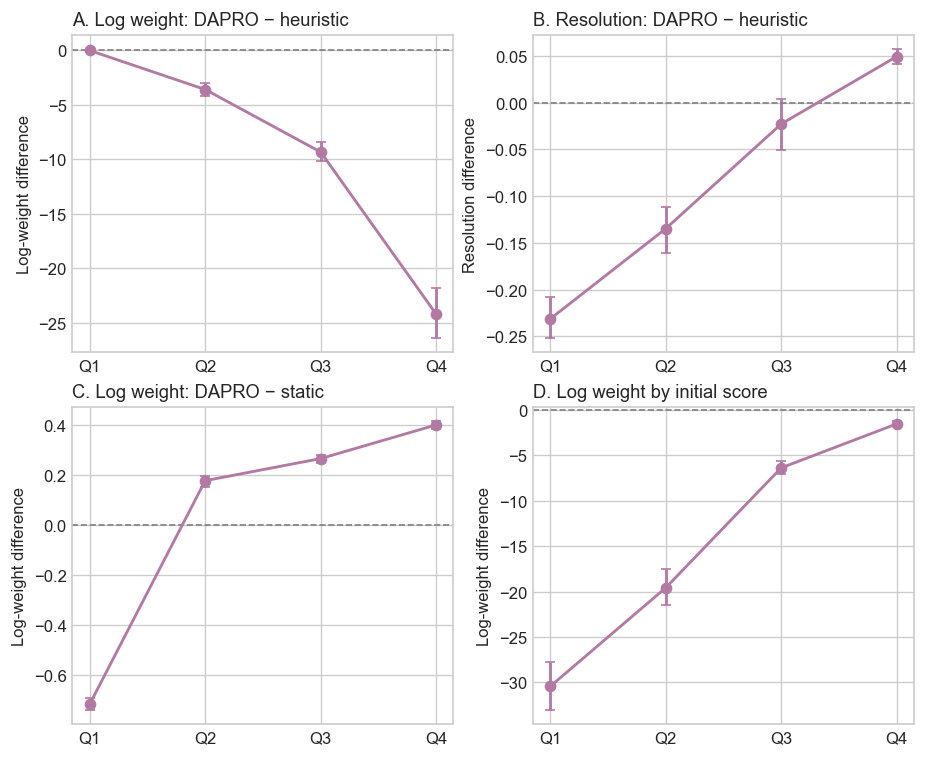

**Interpretation.** Q1 contains relatively early events and Q4 contains late or horizon-limited trajectories. The most favorable DAPRO-minus-heuristic mean log-weight difference occurs in **Q4**: -24.2 (95% CI -26.4 to -21.8); the CI excludes zero. That stratum contributes 100.0% of the DAPRO-versus-heuristic raw weight reduction. There DAPRO spends 1.79 more interactions/sample and its resolution rate is 4.91 pp higher; thus the observed gain is a weight/tail reduction, accompanied by improved resolution. The largest score-stratum reduction occurs in **Q1**. Negative log-weight differences favor DAPRO, while positive resolution differences favor DAPRO. This empirical decomposition does not prove global optimality, and latent-event strata are diagnostic and unavailable during online deployment.

In [13]:
panel_specs = [
    ("event_time_difficulty", "mean_log_terminal_weight_difference",
     "ScoreAdaptive-Heuristic", "A. Log weight: DAPRO − heuristic", "Log-weight difference"),
    ("event_time_difficulty", "resolution_rate_difference",
     "ScoreAdaptive-Heuristic", "B. Resolution: DAPRO − heuristic", "Resolution difference"),
    ("event_time_difficulty", "mean_log_terminal_weight_difference",
     "Static", "C. Log weight: DAPRO − static", "Log-weight difference"),
    ("initial_score_quartile", "mean_log_terminal_weight_difference",
     "ScoreAdaptive-Heuristic", "D. Log weight by initial score", "Log-weight difference"),
]
fig, axes = plt.subplots(2, 2, figsize=(7.6, 6.2), constrained_layout=True)
for ax, (stratification, metric, comparator, title, ylabel) in zip(axes.ravel(), panel_specs):
    part = stratified_gain_summary[
        stratified_gain_summary.stratification.eq(stratification)
        & stratified_gain_summary.metric.eq(metric)
        & stratified_gain_summary.second_method.eq(comparator)
    ].set_index("stratum").reindex(["Q1", "Q2", "Q3", "Q4"])
    mean = part["mean"].to_numpy()
    ax.errorbar(
        np.arange(4), mean,
        yerr=np.vstack([
            mean - part["bootstrap_ci_lower"].to_numpy(),
            part["bootstrap_ci_upper"].to_numpy() - mean,
        ]),
        marker="o", color=COLORS["DAPRO"], linewidth=1.7, capsize=3,
    )
    ax.axhline(0, color="gray", linestyle="--", linewidth=1)
    ax.set_xticks(np.arange(4))
    ax.set_xticklabels(["Q1", "Q2", "Q3", "Q4"])
    ax.set_title(title, loc="left")
    ax.set_ylabel(ylabel)
save_figure(fig, "figure_stratified_gains")
plt.show()

focus = stratified_gain_summary[
    stratified_gain_summary.second_method.eq("ScoreAdaptive-Heuristic")
    & stratified_gain_summary.stratification.eq("event_time_difficulty")
    & stratified_gain_summary.metric.eq("mean_log_terminal_weight_difference")
].copy()
strongest = focus.loc[focus["mean"].idxmin()]
ci_excludes = strongest.bootstrap_ci_upper < 0 or strongest.bootstrap_ci_lower > 0
strongest_resolution = stratified_gain_summary[
    stratified_gain_summary.second_method.eq("ScoreAdaptive-Heuristic")
    & stratified_gain_summary.stratification.eq("event_time_difficulty")
    & stratified_gain_summary.stratum.eq(strongest.stratum)
    & stratified_gain_summary.metric.eq("resolution_rate_difference")
].iloc[0]
strongest_cost = stratified_gain_summary[
    stratified_gain_summary.second_method.eq("ScoreAdaptive-Heuristic")
    & stratified_gain_summary.stratification.eq("event_time_difficulty")
    & stratified_gain_summary.stratum.eq(strongest.stratum)
    & stratified_gain_summary.metric.eq("realized_cost_difference")
].iloc[0]
strongest_share = stratified_gain_summary[
    stratified_gain_summary.second_method.eq("ScoreAdaptive-Heuristic")
    & stratified_gain_summary.stratification.eq("event_time_difficulty")
    & stratified_gain_summary.stratum.eq(strongest.stratum)
    & stratified_gain_summary.metric.eq("weight_reduction_share")
].iloc[0]
resolution_direction = (
    "higher" if strongest_resolution["mean"] > 0
    else "lower" if strongest_resolution["mean"] < 0
    else "unchanged"
)
cost_direction = (
    "more" if strongest_cost["mean"] > 0
    else "less" if strongest_cost["mean"] < 0
    else "the same number of"
)
display(Markdown(
    f"**Interpretation.** Q1 contains relatively early events and Q4 contains late or "
    f"horizon-limited trajectories. The most favorable DAPRO-minus-heuristic mean log-weight "
    f"difference occurs in **{strongest.stratum}**: {strongest['mean']:.3g} "
    f"(95% CI {strongest.bootstrap_ci_lower:.3g} to {strongest.bootstrap_ci_upper:.3g}); "
    f"the CI {'excludes' if ci_excludes else 'includes'} zero. That stratum contributes "
    f"{strongest_share['mean']:.1%} of the DAPRO-versus-heuristic raw weight reduction. "
    f"There DAPRO spends {abs(strongest_cost['mean']):.2f} {cost_direction} interactions/sample "
    f"and its resolution rate is {abs(100 * strongest_resolution['mean']):.2f} pp "
    f"{resolution_direction}; thus the observed gain is a weight/tail reduction, "
    f"{'not an improvement in resolution' if strongest_resolution['mean'] <= 0 else 'accompanied by improved resolution'}. "
    f"The largest score-stratum reduction occurs in **{largest_score}**. Negative log-weight "
    "differences favor DAPRO, while positive resolution differences favor DAPRO. This empirical "
    "decomposition does not prove global optimality, and latent-event strata are diagnostic and "
    "unavailable during online deployment."
))

### 7.1 Stratified proxy and variability comparisons

The additional figure compares DAPRO with both the score-adaptive heuristic and RandomAdaptive. It separates changes in mean log inverse weight, dispersion of log inverse weights, reconstructed resolution, and realized acquisition cost.

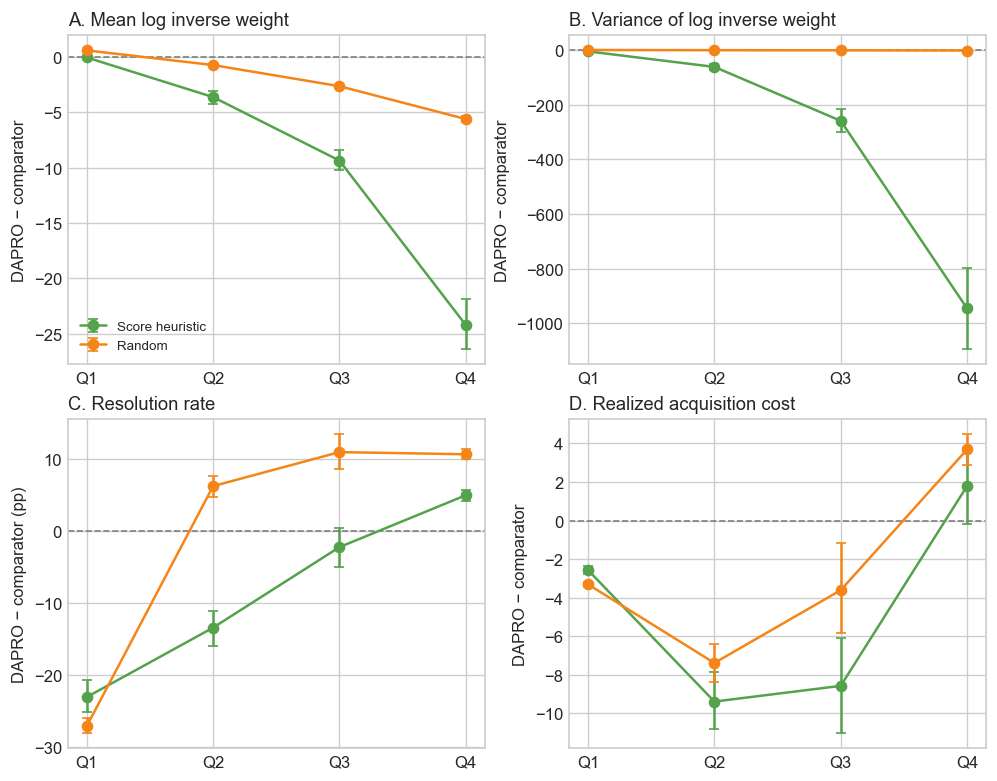

**Interpretation.** Negative mean/variance differences indicate lower inverse-weight level or dispersion for DAPRO; positive resolution differences indicate more resolved calibration trajectories. Against RandomAdaptive in Q4, DAPRO changes mean log weight by -5.60, log-weight variance by -1.90, resolution by +10.60 pp, and cost by +3.68. This determines whether late-trajectory weight gains coincide with more acquisition or better resolution. It cannot establish stratum-specific coverage because the saved test outputs are global and lack per-example LPBs.

In [14]:
variance_panel_specs = [
    ("mean_log_terminal_weight_difference", "A. Mean log inverse weight", 1.0),
    ("log_weight_variance_difference", "B. Variance of log inverse weight", 1.0),
    ("resolution_rate_difference", "C. Resolution rate", 100.0),
    ("realized_cost_difference", "D. Realized acquisition cost", 1.0),
]
variance_comparators = ["ScoreAdaptive-Heuristic", "RandomAdaptive"]
fig, axes = plt.subplots(2, 2, figsize=(8.2, 6.4), constrained_layout=True)
for ax, (metric, title, scale) in zip(axes.ravel(), variance_panel_specs):
    for comparator in variance_comparators:
        part = stratified_gain_summary[
            stratified_gain_summary.second_method.eq(comparator)
            & stratified_gain_summary.stratification.eq("event_time_difficulty")
            & stratified_gain_summary.metric.eq(metric)
        ].set_index("stratum").reindex(["Q1", "Q2", "Q3", "Q4"])
        mean = scale * part["mean"].to_numpy()
        low = scale * part["bootstrap_ci_lower"].to_numpy()
        high = scale * part["bootstrap_ci_upper"].to_numpy()
        ax.errorbar(
            np.arange(4), mean,
            yerr=np.vstack([mean - low, high - mean]),
            marker="o", linewidth=1.5, capsize=3,
            color=COLORS[comparator], label=SHORT_NAMES[comparator],
        )
    ax.axhline(0, color="gray", linestyle="--", linewidth=1)
    ax.set_xticks(np.arange(4))
    ax.set_xticklabels(["Q1", "Q2", "Q3", "Q4"])
    ax.set_title(title, loc="left")
    ax.set_ylabel("DAPRO − comparator" + (" (pp)" if scale == 100 else ""))
axes[0, 0].legend(frameon=False)
save_figure(fig, "figure_stratified_variability")
plt.show()

random_q4 = stratified_gain_summary[
    stratified_gain_summary.second_method.eq("RandomAdaptive")
    & stratified_gain_summary.stratification.eq("event_time_difficulty")
    & stratified_gain_summary.stratum.eq("Q4")
].set_index("metric")
display(Markdown(
    "**Interpretation.** Negative mean/variance differences indicate lower inverse-weight "
    "level or dispersion for DAPRO; positive resolution differences indicate more resolved "
    "calibration trajectories. Against RandomAdaptive in Q4, DAPRO changes mean log weight by "
    f"{random_q4.loc['mean_log_terminal_weight_difference', 'mean']:+.2f}, log-weight "
    f"variance by {random_q4.loc['log_weight_variance_difference', 'mean']:+.2f}, "
    f"resolution by {100 * random_q4.loc['resolution_rate_difference', 'mean']:+.2f} pp, "
    f"and cost by {random_q4.loc['realized_cost_difference', 'mean']:+.2f}. "
    "This determines whether late-trajectory weight gains coincide with more acquisition or "
    "better resolution. It cannot establish stratum-specific coverage because the saved test "
    "outputs are global and lack per-example LPBs."
))


## 8. Coverage, variance, weight, and event resolution by difficulty quartile

Difficulty is the outcome-defined ratio $\min(T_i,q_i)/q_i$: Q1 contains the earliest events and Q4 the latest or horizon-limited trajectories. The table reports raw mean terminal weight, while the figure uses a 99%-trimmed mean so extreme inverse-probability tails do not flatten every other method. Event-time resolution means that acquisition actually reached $T_i$.

Quartile values are **direct split-level columns from the corrected ablation run**.

method,quartile,mean_test_coverage,mean_absolute_coverage_deviation_pp,across_split_coverage_variance,across_split_lpb_variance,mean_test_lpb_variance,mean_terminal_weight,p99_trimmed_mean_terminal_weight,event_resolution_rate,weighted_miscoverage_variance,conditional_acquisition_variance,across_split_coverage_variance_pp2
Static,Q1,0.716,18.38,0.000569,0.007109,0.25,6.35,6.35,16.3%,0.0019,0.00164,5.686
Static,Q2,1.000,10.00,0.000000,0.008588,0.25,6.35,6.35,16.4%,0,0,0.000
Static,Q3,1.000,10.00,0.000000,0.018400,0.28,6.42,6.42,15.2%,0,0,0.000
Static,Q4,1.000,10.00,0.000000,0.041384,0.31,6.52,6.52,0.8%,0,0,0.000
RandomAdaptive,Q1,0.707,19.32,0.000783,0.040013,0.23,1.96,1.89,65.6%,0.000249,2.67e-05,7.827
RandomAdaptive,Q2,1.000,10.00,0.000000,0.041300,0.23,21.6,20.7,7.8%,0,0,0.000
RandomAdaptive,Q3,1.000,10.00,0.000000,0.055566,0.27,208,200,1.6%,0,0,0.000
RandomAdaptive,Q4,1.000,10.00,0.000000,0.109363,0.31,5.58e+03,5.58e+03,0.0%,0,0,0.000
ScoreAdaptive-Heuristic,Q1,0.706,19.42,0.001066,0.041492,0.27,4.95e+07,1.76e+03,61.5%,0.000314,0.000127,10.661
ScoreAdaptive-Heuristic,Q2,1.000,10.00,0.000000,0.036412,0.25,6.26e+16,5.99e+14,27.5%,0,0,0.000


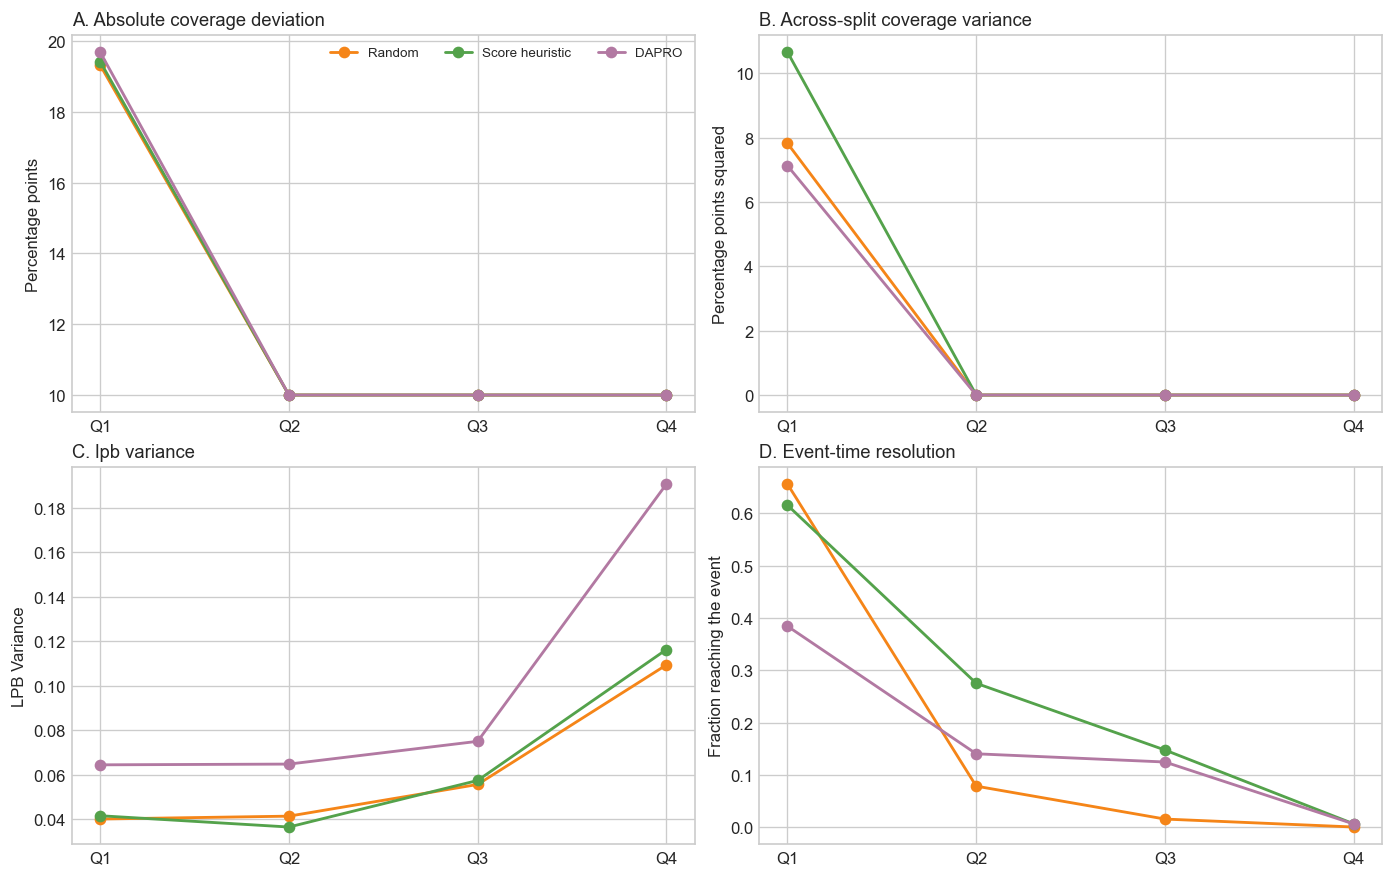

**DAPRO versus Random:** lower mean coverage deviation in no quartile; lower across-split coverage variance in ['Q1']; lower raw mean weight in ['Q2', 'Q3', 'Q4']; higher event-time resolution in ['Q2', 'Q3', 'Q4'].

**DAPRO versus Score heuristic:** lower mean coverage deviation in no quartile; lower across-split coverage variance in ['Q1']; lower raw mean weight in ['Q1', 'Q2', 'Q3', 'Q4']; higher event-time resolution in no quartile.

In [15]:
quartile_labels = ["Q1", "Q2", "Q3", "Q4"]
target_coverage = 1.0 - float(metadata["config"]["target_miscoverage"])
direct_quartile_columns = {
    f"difficulty_{quartile}_{suffix}"
    for quartile in quartile_labels
    for suffix in (
        "test_coverage", "absolute_coverage_deviation", "test_lpb_variance",
        "mean_terminal_weight", "p99_trimmed_mean_terminal_weight",
        "event_resolution_rate", "weighted_miscoverage_variance",
        "conditional_acquisition_variance", "phase2_count", "test_count",
    )
}

quartile_rows = []
if direct_quartile_columns.issubset(split_df.columns):
    quartile_source = "direct split-level columns from the corrected ablation run"
    for _, split_row in split_df.iterrows():
        for quartile in quartile_labels:
            prefix = f"difficulty_{quartile}_"
            quartile_rows.append({
                "split_id": int(split_row.split_id), "method": split_row.method,
                "quartile": quartile,
                "test_coverage": split_row[prefix + "test_coverage"],
                "absolute_coverage_deviation_pp": 100 * split_row[prefix + "absolute_coverage_deviation"],
                "test_lpb_variance": split_row[prefix + "test_lpb_variance"],
                "mean_terminal_weight": split_row[prefix + "mean_terminal_weight"],
                "p99_trimmed_mean_terminal_weight": split_row[prefix + "p99_trimmed_mean_terminal_weight"],
                "event_resolution_rate": split_row[prefix + "event_resolution_rate"],
                "weighted_miscoverage_variance": split_row[prefix + "weighted_miscoverage_variance"],
                "conditional_acquisition_variance": split_row[prefix + "conditional_acquisition_variance"],
                "n_calibration_phase2": split_row[prefix + "phase2_count"],
                "n_test": split_row[prefix + "test_count"],
            })
else:
    quartile_source = "reconstructed from the cached prediction tensor and legacy sample rows"
    source_paths = [Path(path) for path in metadata["source_files"]]
    prediction_path = next(path for path in source_paths if path.name == "probability_est_cal_test.pt")
    data_dir = next(path.parent for path in source_paths if path.name == "t_tilde_train.npy")
    event_all = np.concatenate([
        np.load(data_dir / "t_tilde_train.npy"),
        np.load(data_dir / "t_tilde_cal.npy"),
        np.load(data_dir / "t_tilde_test.npy"),
    ])
    np.random.RandomState(0).shuffle(event_all)
    n_train = len(np.load(data_dir / "t_tilde_train.npy", mmap_mode="r"))
    event_times = event_all[n_train:]
    tau_grid = np.logspace(-3, -0.01, 1000)
    tau_prior_grid = float(tau_grid[np.argmin(np.abs(tau_grid - metadata["config"]["tau_prior"]))])
    requested_levels = np.unique(np.r_[tau_prior_grid, split_df.selected_tau.to_numpy(float)])
    probability = torch.load(prediction_path, map_location="cpu", weights_only=False)
    probability_mass = probability[:, 0, :].float().add_(1e-10)
    probability_mass.div_(probability_mass.sum(dim=1, keepdim=True))
    cumulative = probability_mass[:, :-1].cumsum(dim=1).contiguous()
    queries = torch.as_tensor(requested_levels, dtype=cumulative.dtype).expand(len(cumulative), -1).contiguous()
    quantile_cache = torch.searchsorted(cumulative, queries, right=False).clamp(max=probability.shape[-1] - 1).numpy()
    del probability, probability_mass, cumulative, queries

    def cached_quantile_at(level):
        return quantile_cache[:, int(np.argmin(np.abs(requested_levels - level)))]

    q_prior_cache = cached_quantile_at(tau_prior_grid)
    sample_check = sample_df.drop_duplicates(["split_id", "sample_id"])
    check_ids = sample_check.sample_id.to_numpy(int)
    if not np.array_equal(sample_check.T_i.to_numpy(int), event_times[check_ids]):
        raise AssertionError("Cached event times do not match the saved sample rows.")
    if not np.array_equal(sample_check.q_prior_i.to_numpy(int), q_prior_cache[check_ids]):
        raise AssertionError("Cached prior quantiles do not match the legacy sample rows.")
    cal_size = int(metadata.get("cal_size", sample_df.loc[sample_df.split_id.eq(sample_df.split_id.min()), "sample_id"].nunique() + metadata["config"]["n1"]))
    for split_id in sorted(split_df.split_id.unique()):
        permutation = np.random.RandomState(int(split_id)).permutation(len(event_times))
        test_ids = permutation[cal_size:]
        test_event = event_times[test_ids]
        test_prior = q_prior_cache[test_ids]
        test_ratio = np.divide(
            np.minimum(test_event, test_prior), test_prior,
            out=np.zeros(len(test_ids), dtype=float), where=test_prior > 0,
        )
        test_quartile = np.asarray(quartile_labels)[np.clip(np.searchsorted([0.25, 0.50, 0.75, 1.0], test_ratio, side="left"), 0, 3)]
        for _, split_row in split_df.loc[split_df.split_id.eq(split_id)].iterrows():
            selected_bound = cached_quantile_at(float(split_row.selected_tau))
            test_bound = selected_bound[test_ids]
            cal = sample_df.loc[
                sample_df.split_id.eq(split_id) & sample_df.method.eq(split_row.method)
            ].copy()
            cal_ids = cal.sample_id.to_numpy(int)
            cal["selected_latent_miscoverage"] = (cal.T_i.to_numpy(int) < selected_bound[cal_ids]).astype(float)
            cal["selected_estimable_miscoverage"] = cal.selected_latent_miscoverage * (selected_bound[cal_ids] <= cal.q_prior_i.to_numpy(int))
            cal["selected_weighted_contribution"] = (
                cal.latent_terminal_weight * cal.selected_latent_miscoverage * cal.event_observed_indicator
            )
            cal["conditional_variance_term"] = cal.selected_estimable_miscoverage * (cal.latent_terminal_weight - 1.0)
            for quartile in quartile_labels:
                test_mask = test_quartile == quartile
                coverage = float(np.mean(test_event[test_mask] >= test_bound[test_mask]))
                lpb_variance = float(np.var(test_bound[test_mask], ddof=1)) if test_mask.sum() > 1 else 0.0
                group = cal.loc[cal.difficulty_stratum.eq(quartile)]
                weights = group.latent_terminal_weight.to_numpy(float)
                values = group.selected_weighted_contribution.to_numpy(float)
                trim_threshold = np.quantile(weights, 0.99)
                n_group = len(group)
                quartile_rows.append({
                    "split_id": int(split_id), "method": split_row.method, "quartile": quartile,
                    "test_coverage": coverage,
                    "absolute_coverage_deviation_pp": 100 * abs(coverage - target_coverage),
                    "test_lpb_variance": lpb_variance,
                    "mean_terminal_weight": float(np.mean(weights)),
                    "p99_trimmed_mean_terminal_weight": float(np.mean(weights[weights <= trim_threshold])),
                    "event_resolution_rate": float(group.event_observed_indicator.mean()),
                    "weighted_miscoverage_variance": float(np.var(values, ddof=1) / n_group) if n_group > 1 else 0.0,
                    "conditional_acquisition_variance": float(group.conditional_variance_term.sum() / n_group**2),
                    "n_calibration_phase2": n_group, "n_test": int(test_mask.sum()),
                })

quartile_raw = pd.DataFrame(quartile_rows)
quartile_raw.to_csv(OUTPUT_DIR / "difficulty_quartile_performance_raw.csv", index=False)
quartile_summary = (
    quartile_raw.groupby(["method", "quartile"], observed=True)
    .agg(
        mean_test_coverage=("test_coverage", "mean"),
        mean_absolute_coverage_deviation_pp=("absolute_coverage_deviation_pp", "mean"),
        across_split_coverage_variance=("test_coverage", "var"),
        across_split_lpb_variance=("test_lpb_variance", "var"),
        mean_test_lpb_variance=("test_lpb_variance", "mean"),
        mean_terminal_weight=("mean_terminal_weight", "mean"),
        p99_trimmed_mean_terminal_weight=("p99_trimmed_mean_terminal_weight", "mean"),
        event_resolution_rate=("event_resolution_rate", "mean"),
        weighted_miscoverage_variance=("weighted_miscoverage_variance", "mean"),
        conditional_acquisition_variance=("conditional_acquisition_variance", "mean"),
    ).reset_index()
)
quartile_summary["across_split_coverage_variance_pp2"] = 10_000 * quartile_summary.across_split_coverage_variance
quartile_summary.method = pd.Categorical(quartile_summary.method, METHOD_ORDER, ordered=True)
quartile_summary.quartile = pd.Categorical(quartile_summary.quartile, quartile_labels, ordered=True)
quartile_summary = quartile_summary.sort_values(["method", "quartile"]).reset_index(drop=True)
quartile_summary.to_csv(OUTPUT_DIR / "difficulty_quartile_performance_summary.csv", index=False)

display(Markdown(f"Quartile values are **{quartile_source}**."))
display(quartile_summary.style.format({
    "mean_test_coverage": "{:.3f}", "mean_absolute_coverage_deviation_pp": "{:.2f}",
    "across_split_coverage_variance_pp2": "{:.3f}", "mean_test_lpb_variance": "{:.2f}",
    "mean_terminal_weight": "{:.3g}", "p99_trimmed_mean_terminal_weight": "{:.3g}",
    "event_resolution_rate": "{:.1%}", "weighted_miscoverage_variance": "{:.3g}",
    "conditional_acquisition_variance": "{:.3g}",
}).hide(axis="index"))

fig, axes = plt.subplots(2, 2, figsize=(11.5, 7.2), constrained_layout=True)
quartile_plot_specs = [
    ("mean_absolute_coverage_deviation_pp", "A. Absolute coverage deviation", "Percentage points"),
    ("across_split_coverage_variance_pp2", "B. Across-split coverage variance", "Percentage points squared"),
    # ("p99_trimmed_mean_terminal_weight", "C. 99%-trimmed mean terminal weight", "Inverse probability"),
    ("across_split_lpb_variance", "C. lpb variance", "LPB Variance"),
    ("event_resolution_rate", "D. Event-time resolution", "Fraction reaching the event"),
]
METHOD_ORDER = [method for method in METHOD_ORDER if 'local' not in method.lower() and 'static' not in method.lower()]
for ax, (metric, title, ylabel) in zip(axes.flat, quartile_plot_specs):
    
    panel_methods = (
        [method for method in METHOD_ORDER if method != "ScoreAdaptive-Heuristic" and 'local' not in method.lower() and 'static' not in method.lower()]
        if metric == "p99_trimmed_mean_terminal_weight" else METHOD_ORDER
    )
    for method in panel_methods:
        values = quartile_summary.loc[quartile_summary.method.eq(method)].set_index("quartile").reindex(quartile_labels)
        ax.plot(quartile_labels, values[metric], marker="o", linewidth=1.7, label=SHORT_NAMES[method], color=COLORS[method])
    ax.set_title(title, loc="left")
    ax.set_ylabel(ylabel)
    if metric == "p99_trimmed_mean_terminal_weight":
        ax.set_yscale("log")
        ax.text(
            0.02, 0.98, "Score heuristic omitted (off-scale); see table",
            transform=ax.transAxes, va="top", fontsize=8,
        )
axes[0, 0].legend(ncol=3, fontsize=8)
save_figure(fig, "figure_difficulty_quartile_performance")
plt.show()

for comparator in ("RandomAdaptive", "ScoreAdaptive-Heuristic"):
    comparison = quartile_summary[quartile_summary.method.isin(["DAPRO", comparator])].pivot(index="quartile", columns="method")
    better_error = [q for q in quartile_labels if comparison["mean_absolute_coverage_deviation_pp"].loc[q, "DAPRO"] < comparison["mean_absolute_coverage_deviation_pp"].loc[q, comparator]]
    better_variance = [q for q in quartile_labels if comparison["across_split_coverage_variance_pp2"].loc[q, "DAPRO"] < comparison["across_split_coverage_variance_pp2"].loc[q, comparator]]
    better_weight = [q for q in quartile_labels if comparison["mean_terminal_weight"].loc[q, "DAPRO"] < comparison["mean_terminal_weight"].loc[q, comparator]]
    better_resolution = [q for q in quartile_labels if comparison["event_resolution_rate"].loc[q, "DAPRO"] > comparison["event_resolution_rate"].loc[q, comparator]]
    display(Markdown(
        f"**DAPRO versus {SHORT_NAMES[comparator]}:** lower mean coverage deviation in {better_error or 'no quartile'}; "
        f"lower across-split coverage variance in {better_variance or 'no quartile'}; lower raw mean weight in {better_weight or 'no quartile'}; "
        f"higher event-time resolution in {better_resolution or 'no quartile'}."
    ))


### Why lower mean weight need not win these empirical metrics

At a fixed candidate LPB, let $A_i=\mathbf{1}\{T_i<f_\lambda(X_i)\leq q_i\}$ and let $w_i=1/\pi_i$. Conditional on the trajectory and policy, the acquisition contribution has variance $A_i(w_i-1)$, not simply $w_i$. The paper replaces this event-localized quantity by the looser uniform bound $\mathbb{E}[w_i]\leq\bar w$ to obtain a one-sided PAC slack. Consequently, reducing global mean weight tightens that worst-case bound but does not impose a monotone ordering on realized variance, absolute two-sided coverage error, or their post-selection estimates.

The constant-random policy is constant **per interaction**, so its terminal inclusion probability is $p^{\min(T_i,q_i)}$. It preferentially resolves short Q1 trajectories, while its largest weights accumulate on long Q4 trajectories. For the selected LPB, miscoverage is concentrated in Q1 and $A_i$ is essentially zero in Q2--Q4; therefore the enormous late-trajectory weights are multiplied by zero in the selected weighted loss. DAPRO optimizes global terminal weight across all trajectories, but can allocate less observation probability to precisely the early-event Q1 samples driving this selected estimator. This is why Random or the score heuristic can show a smaller realized variance despite a much worse raw mean-weight tail.

These quartiles depend on the realized event time, so they are diagnostic outcome-defined classes rather than pre-event deployment groups. Also, the selected threshold and the displayed weighted variance use the same calibration split; both are descriptive after model selection, whereas the theorem's $\bar w$ is an almost-sure phase-I-conditioned bound.

## 9. Tail-weight concentration

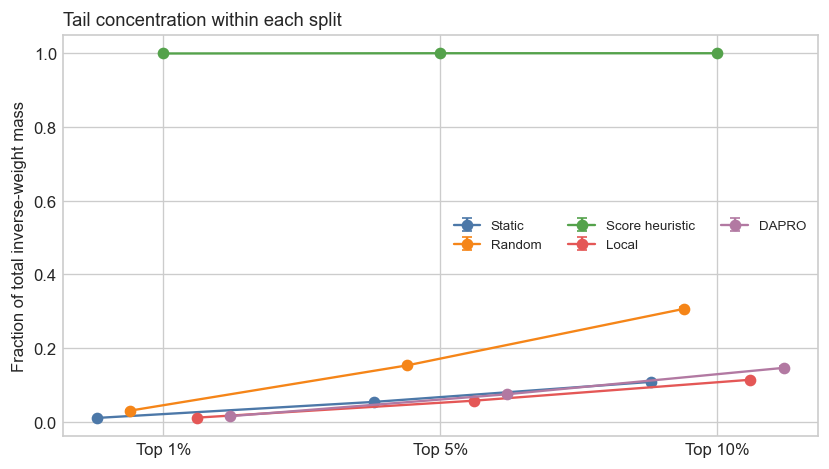

**Interpretation.** Tail fractions are computed within each split before averaging, so every split contributes equally. This tests whether an average-weight failure is driven by a small number of trajectories. DAPRO reduces top-10% weight-mass concentration from 100.0% to 14.7% relative to the score heuristic, indicating tail compression rather than only a shift in the average. DAPRO's top-10% concentration is 14.7% versus 30.7% for RandomAdaptive. The top 1% alone contributes 99.9% for the heuristic versus 1.6% for DAPRO. DAPRO compresses the tail relative to the score heuristic and RandomAdaptive, but not relative to every baseline; this tail result does not erase the unfavorable downstream variance comparisons, and latent weights are unavailable online.

In [16]:
tail_rows = []
for (split_id, method), group in sample_df.groupby(["split_id", "method"], observed=True):
    weights = np.sort(group["latent_terminal_weight"].to_numpy(dtype=float))[::-1]
    total = weights.sum()
    row = {"split_id": int(split_id), "method": str(method), "gini": gini(weights)}
    for pct in (0.01, 0.05, 0.10):
        count = max(1, int(math.ceil(pct * len(weights))))
        row[f"top_{int(100 * pct)}pct_weight_mass_fraction"] = float(weights[:count].sum() / total)
    tail_rows.append(row)
tail_by_split = pd.DataFrame(tail_rows)
tail_by_split.to_csv(OUTPUT_DIR / "tail_concentration_by_split.csv", index=False)

tail_methods = ["Static", "RandomAdaptive", "ScoreAdaptive-Heuristic", "LocallyAdaptive", "DAPRO"]
tail_metrics = [
    ("top_1pct_weight_mass_fraction", "Top 1%"),
    ("top_5pct_weight_mass_fraction", "Top 5%"),
    ("top_10pct_weight_mass_fraction", "Top 10%"),
]
fig, ax = plt.subplots(figsize=(6.8, 3.8), constrained_layout=True)
offsets = np.linspace(-0.24, 0.24, len(tail_methods))
x = np.arange(len(tail_metrics))
tail_aggregate = {}
for method_index, method in enumerate(tail_methods):
    means, lows, highs = [], [], []
    for metric_index, (metric, _) in enumerate(tail_metrics):
        values = tail_by_split.loc[tail_by_split.method.eq(method), metric].to_numpy()
        mean = float(np.mean(values))
        lo, hi = bootstrap_mean_ci(
            values, BOOTSTRAP_SEED + 3_000 + method_index * 10 + metric_index
        )
        means.append(mean)
        lows.append(mean - lo)
        highs.append(hi - mean)
        tail_aggregate[(method, metric)] = {"mean": mean, "ci": [lo, hi]}
    ax.errorbar(
        x + offsets[method_index], means, yerr=np.vstack([lows, highs]),
        marker="o", linewidth=1.4, capsize=3, color=COLORS[method],
        label=SHORT_NAMES[method],
    )
ax.set_xticks(x)
ax.set_xticklabels([label for _, label in tail_metrics])
ax.set_ylabel("Fraction of total inverse-weight mass")
ax.set_title("Tail concentration within each split", loc="left")
ax.legend(frameon=False, ncol=3)
save_figure(fig, "figure_tail_concentration")
plt.show()

dapro_top10 = tail_aggregate[("DAPRO", "top_10pct_weight_mass_fraction")]["mean"]
heuristic_top10 = tail_aggregate[("ScoreAdaptive-Heuristic", "top_10pct_weight_mass_fraction")]["mean"]
random_top10 = tail_aggregate[("RandomAdaptive", "top_10pct_weight_mass_fraction")]["mean"]
if dapro_top10 < heuristic_top10:
    tail_text = (
        f"DAPRO reduces top-10% weight-mass concentration from {heuristic_top10:.1%} "
        f"to {dapro_top10:.1%} relative to the score heuristic, indicating tail compression "
        "rather than only a shift in the average."
    )
else:
    tail_text = (
        f"DAPRO's top-10% concentration ({dapro_top10:.1%}) is not lower than the score "
        f"heuristic's ({heuristic_top10:.1%}); the data do not support tail compression."
    )
dapro_top1 = tail_aggregate[("DAPRO", "top_1pct_weight_mass_fraction")]["mean"]
heuristic_top1 = tail_aggregate[
    ("ScoreAdaptive-Heuristic", "top_1pct_weight_mass_fraction")
]["mean"]
random_tail_text = (
    f"DAPRO's top-10% concentration is {dapro_top10:.1%} versus "
    f"{random_top10:.1%} for RandomAdaptive."
)
display(Markdown(
    "**Interpretation.** Tail fractions are computed within each split before averaging, so "
    "every split contributes equally. This tests whether an average-weight failure is driven "
    "by a small number of trajectories. "
    + tail_text
    + " "
    + random_tail_text
    + f" The top 1% alone contributes {heuristic_top1:.1%} for the heuristic versus "
    f"{dapro_top1:.1%} for DAPRO. DAPRO compresses the tail relative to the score heuristic "
    "and RandomAdaptive, but not relative to every baseline; this tail result does not erase "
    "the unfavorable downstream variance comparisons, and latent weights are unavailable online."
))

## 10. Rebuttal-ready Markdown tables and text

In [17]:
def paired_row(comparator, metric):
    return paired_results[
        paired_results.first_method.eq("DAPRO")
        & paired_results.second_method.eq(comparator)
        & paired_results.metric.eq(metric)
    ].iloc[0]


def compact_ci(row, fmt=".3g"):
    return (
        f"{format(row.mean_paired_difference, fmt)} "
        f"[{format(row.bootstrap_ci_lower, fmt)}, {format(row.bootstrap_ci_upper, fmt)}]"
    )


main_rows = []
for comparator, label in [
    ("ScoreAdaptive-Heuristic", "Score-adaptive heuristic"),
    ("RandomAdaptive", "Random adaptive"),
    ("LocallyAdaptive", "Locally adaptive"),
    ("Static", "Static"),
]:
    coverage = paired_row(comparator, "absolute_coverage_deviation_pp")
    weight = paired_row(comparator, "phase2_mean_latent_terminal_weight")
    variance = paired_row(comparator, "weighted_miscoverage_variance")
    main_rows.append([
        label,
        compact_ci(coverage, ".2f"),
        compact_ci(weight, ".2g"),
        compact_ci(variance, ".2g"),
        f"{coverage.fraction_first_better:.0%}",
    ])
rebuttal_main_table = markdown_table(
    [
        "Comparator",
        "Δ coverage error ↓ (pp)",
        "Δ mean latent inverse weight ↓",
        "Δ weighted-miscoverage variance ↓",
        "Coverage-error win rate",
    ],
    main_rows,
) + f"\n\nPaired over {n_splits} random splits; negative differences favor DAPRO."
(OUTPUT_DIR / "rebuttal_main_table.md").write_text(rebuttal_main_table + "\n", encoding="utf-8",)

strat_rows = []
for stratum in difficulty_order:
    log_row = stratified_gain_summary[
        stratified_gain_summary.second_method.eq("ScoreAdaptive-Heuristic")
        & stratified_gain_summary.stratification.eq("event_time_difficulty")
        & stratified_gain_summary.stratum.eq(stratum)
        & stratified_gain_summary.metric.eq("mean_log_terminal_weight_difference")
    ].iloc[0]
    resolution_row = stratified_gain_summary[
        stratified_gain_summary.second_method.eq("ScoreAdaptive-Heuristic")
        & stratified_gain_summary.stratification.eq("event_time_difficulty")
        & stratified_gain_summary.stratum.eq(stratum)
        & stratified_gain_summary.metric.eq("resolution_rate_difference")
    ].iloc[0]
    static_share_row = stratified_gain_summary[
        stratified_gain_summary.second_method.eq("Static")
        & stratified_gain_summary.stratification.eq("event_time_difficulty")
        & stratified_gain_summary.stratum.eq(stratum)
        & stratified_gain_summary.metric.eq("weight_reduction_share")
    ].iloc[0]
    heuristic_share_row = stratified_gain_summary[
        stratified_gain_summary.second_method.eq("ScoreAdaptive-Heuristic")
        & stratified_gain_summary.stratification.eq("event_time_difficulty")
        & stratified_gain_summary.stratum.eq(stratum)
        & stratified_gain_summary.metric.eq("weight_reduction_share")
    ].iloc[0]
    strat_rows.append([
        stratum,
        f"{log_row['mean']:.2f} [{log_row.bootstrap_ci_lower:.2f}, {log_row.bootstrap_ci_upper:.2f}]",
        f"{100 * resolution_row['mean']:.2f} [{100 * resolution_row.bootstrap_ci_lower:.2f}, {100 * resolution_row.bootstrap_ci_upper:.2f}]",
        f"{heuristic_share_row['mean']:.1%}",
        f"{static_share_row['mean']:.1%}",
    ])
rebuttal_stratified_table = markdown_table(
    [
        "Difficulty",
        "Δ mean log inverse weight vs heuristic",
        "Δ resolution vs heuristic (pp)",
        "Share of Σ(w_heuristic−w_DAPRO)",
        "Share of Σ(w_static−w_DAPRO)",
    ],
    strat_rows,
) + "\n\nShares are of total latent inverse-weight reduction within each split; negative values mean the stratum offsets gains elsewhere. Q4 contains the latest or prior-horizon-limited trajectories."
(OUTPUT_DIR / "rebuttal_stratified_table.md").write_text(
    rebuttal_stratified_table + "\n",
    encoding="utf-8",
)

heuristic_coverage = paired_row("ScoreAdaptive-Heuristic", "absolute_coverage_deviation_pp")
heuristic_weight = paired_row("ScoreAdaptive-Heuristic", "phase2_mean_latent_terminal_weight")
heuristic_variance = paired_row("ScoreAdaptive-Heuristic", "weighted_miscoverage_variance")
heuristic_budget = paired_row("ScoreAdaptive-Heuristic", "realized_total_budget_per_sample")
random_coverage = paired_row("RandomAdaptive", "absolute_coverage_deviation_pp")
random_weight = paired_row("RandomAdaptive", "phase2_mean_latent_terminal_weight")
random_variance = paired_row("RandomAdaptive", "weighted_miscoverage_variance")
best_share = stratified_gain_summary[
    stratified_gain_summary.second_method.eq("ScoreAdaptive-Heuristic")
    & stratified_gain_summary.stratification.eq("event_time_difficulty")
    & stratified_gain_summary.stratum.eq(largest_difficulty)
    & stratified_gain_summary.metric.eq("weight_reduction_share")
].iloc[0]["mean"]

def evidence_phrase(row, label, unit="", precision=".3g"):
    estimate = format(abs(row.mean_paired_difference), precision)
    ci = (
        f"[{format(row.bootstrap_ci_lower, precision)}, "
        f"{format(row.bootstrap_ci_upper, precision)}]"
    )
    favorable = row.mean_paired_difference < 0
    confirmed = favorable and row.bootstrap_ci_upper < 0 and row.wilcoxon_p_holm < TEST_ALPHA
    if confirmed:
        return (
            f"DAPRO reduced {label} by {estimate}{unit} (difference CI {ci}; "
            f"Holm-adjusted p={row.wilcoxon_p_holm:.3g})"
        )
    if favorable:
        return (
            f"DAPRO showed a numerical reduction in {label} of {estimate}{unit}, "
            f"although the CI {ci} includes zero or the adjusted test does not pass"
        )
    return (
        f"DAPRO did not improve {label} (mean difference "
        f"{format(row.mean_paired_difference, precision)}{unit}; CI {ci})"
    )

ultra_text = (
    "To isolate optimization from generic adaptivity, we compared DAPRO with a score-adaptive "
    f"heuristic using identical scores, budgets, {n_splits} paired splits, and common random numbers, "
    "but without inverse-weight optimization. "
    + evidence_phrase(heuristic_coverage, "absolute coverage error", " pp", ".2f")
    + "; "
    + evidence_phrase(heuristic_weight, "mean latent inverse weight", "", ".2g")
    + f". The largest mean weight reduction occurred in {largest_difficulty} difficulty trajectories; "
    f"that stratum accounted for {best_share:.1%} of the DAPRO-vs-heuristic reduction."
)
ultra = counted_markdown(ultra_text)
assert len(ultra) <= 900
(OUTPUT_DIR / "rebuttal_snippet_ultrashort.md").write_text(ultra,encoding="utf-8",)

budget_sentence = (
    f"DAPRO's average consumed budget differed from the score heuristic by "
    f"{heuristic_budget.mean_paired_difference:+.2f} interactions per calibration sample; "
    "budget is reported descriptively because lower spending is not automatically better."
)
standard_text = (
    "We separated inverse-weight optimization from generic adaptivity by comparing DAPRO with "
    f"a score-adaptive heuristic using the same score, target budget, {n_splits} splits, and "
    "common random numbers. "
    + evidence_phrase(heuristic_coverage, "absolute coverage error", " pp", ".2f")
    + ". "
    + evidence_phrase(heuristic_weight, "mean latent inverse weight", "", ".2g")
    + ". "
    + evidence_phrase(heuristic_variance, "weighted-loss variance", "", ".2g")
    + f". {budget_sentence} The largest weight reduction occurred in {largest_difficulty} "
    f"difficulty trajectories ({best_share:.1%} of the DAPRO-vs-heuristic reduction). "
    + tail_text
    + f" Against RandomAdaptive, DAPRO's differences were "
    f"{random_coverage.mean_paired_difference:+.2f} pp coverage error, "
    f"{random_weight.mean_paired_difference:.2g} mean inverse weight, and "
    f"{random_variance.mean_paired_difference:+.2g} weighted-miscoverage variance; "
    "the random baseline is therefore not dominated on downstream metrics."
)
candidate_with_table = standard_text + "\n\n" + rebuttal_main_table
standard = counted_markdown(
    candidate_with_table if len(counted_markdown(candidate_with_table)) <= 1800 else standard_text
)
assert len(standard) <= 1800
(OUTPUT_DIR / "rebuttal_snippet_standard.md").write_text(standard)

display(Markdown("### Compact main table\n\n" + rebuttal_main_table))
display(Markdown("### Stratified table\n\n" + rebuttal_stratified_table))
display(Markdown("### Ultra-short rebuttal text\n\n" + ultra_text))

### Compact main table

| Comparator | Δ coverage error ↓ (pp) | Δ mean latent inverse weight ↓ | Δ weighted-miscoverage variance ↓ | Coverage-error win rate |
|---|---:|---:|---:|---:|
| Score-adaptive heuristic | -0.09 [-0.27, 0.11] | -1.4e+56 [-3.5e+56, -1.2e+54] | 5.3e-06 [3.6e-06, 6.9e-06] | 70% |
| Random adaptive | -0.04 [-0.17, 0.12] | -3.2e+03 [-4.2e+03, -2.3e+03] | 1.2e-05 [9.9e-06, 1.4e-05] | 50% |
| Locally adaptive | -0.62 [-1.10, -0.14] | 1.2 [1.1, 1.2] | -0.00014 [-0.00015, -0.00013] | 70% |
| Static | -0.07 [-0.57, 0.36] | 1.1 [1.1, 1.2] | -0.00015 [-0.00016, -0.00014] | 40% |

Paired over 10 random splits; negative differences favor DAPRO.

### Stratified table

| Difficulty | Δ mean log inverse weight vs heuristic | Δ resolution vs heuristic (pp) | Share of Σ(w_heuristic−w_DAPRO) | Share of Σ(w_static−w_DAPRO) |
|---|---:|---:|---:|---:|
| Q1 | -0.03 [-0.14, 0.06] | -23.11 [-25.14, -20.75] | 0.0% | nan% |
| Q2 | -3.61 [-4.21, -3.03] | -13.47 [-16.08, -11.12] | 0.0% | nan% |
| Q3 | -9.35 [-10.18, -8.44] | -2.29 [-5.04, 0.36] | 0.0% | nan% |
| Q4 | -24.21 [-26.39, -21.84] | 4.91 [4.13, 5.68] | 100.0% | nan% |

Shares are of total latent inverse-weight reduction within each split; negative values mean the stratum offsets gains elsewhere. Q4 contains the latest or prior-horizon-limited trajectories.

### Ultra-short rebuttal text

To isolate optimization from generic adaptivity, we compared DAPRO with a score-adaptive heuristic using identical scores, budgets, 10 paired splits, and common random numbers, but without inverse-weight optimization. DAPRO showed a numerical reduction in absolute coverage error of 0.09 pp, although the CI [-0.27, 0.11] includes zero or the adjusted test does not pass; DAPRO reduced mean latent inverse weight by 1.4e+56 (difference CI [-3.5e+56, -1.2e+54]; Holm-adjusted p=0.041). The largest mean weight reduction occurred in Q4 difficulty trajectories; that stratum accounted for 100.0% of the DAPRO-vs-heuristic reduction.

## 11. Main conclusions and limitations

In [18]:
conclusion_rows = []
for comparator in ["ScoreAdaptive-Heuristic", "RandomAdaptive", "LocallyAdaptive", "Static"]:
    row = paired_row(comparator, "absolute_coverage_deviation_pp")
    if row.mean_paired_difference < 0 and row.bootstrap_ci_upper < 0 and row.wilcoxon_p_holm < TEST_ALPHA:
        conclusion_rows.append(
            f"- Against **{comparator}**, DAPRO reduced absolute coverage error by "
            f"{abs(row.mean_paired_difference):.2f} pp "
            f"(95% CI {row.bootstrap_ci_lower:.2f} to {row.bootstrap_ci_upper:.2f}; "
            f"Holm p={row.wilcoxon_p_holm:.3g})."
        )
    elif row.mean_paired_difference < 0:
        conclusion_rows.append(
            f"- Against **{comparator}**, DAPRO showed a numerical coverage-error reduction "
            f"of {abs(row.mean_paired_difference):.2f} pp, but the CI or adjusted test is inconclusive."
        )
    else:
        conclusion_rows.append(
            f"- Against **{comparator}**, DAPRO did not reduce absolute coverage error "
            f"(mean difference {row.mean_paired_difference:+.2f} pp)."
        )
score_weight = paired_result(
    "ScoreAdaptive-Heuristic", "phase2_mean_latent_terminal_weight"
)
score_variance = paired_result(
    "ScoreAdaptive-Heuristic", "weighted_miscoverage_variance"
)
random_weight = paired_result("RandomAdaptive", "phase2_mean_latent_terminal_weight")
random_variance = paired_result("RandomAdaptive", "weighted_miscoverage_variance")
conclusion_rows.extend([
    (
        f"- **Proxy versus downstream:** against the score heuristic, DAPRO's mean inverse-weight "
        f"difference is {score_weight.mean_paired_difference:.3g}, while its weighted-miscoverage "
        f"variance difference is {score_variance.mean_paired_difference:+.3g}. The proxy improves "
        "but the saved calibrated-variance diagnostic worsens."
    ),
    (
        f"- **Random baseline:** DAPRO's mean inverse-weight difference versus RandomAdaptive is "
        f"{random_weight.mean_paired_difference:.3g}, but its weighted-miscoverage variance "
        f"difference is {random_variance.mean_paired_difference:+.3g}. The completed experiment "
        "does not establish downstream dominance over RandomAdaptive."
    ),
])
limitations = [
    "Random splits reuse the same underlying dataset; they are paired perturbations, not new independent datasets.",
    "Latent terminal inverse weight and true-event difficulty strata are offline diagnostic quantities.",
    "The ablation establishes empirical contribution under this setup, not global optimality of DAPRO.",
    "Larger LPBs are useful only at comparable empirical coverage.",
    "The saved outputs do not contain per-test-example LPBs or test prompt strata, so Q1–Q4 coverage and within-test LPB variance cannot be reconstructed.",
    "Choosing a metric because it favors DAPRO after observing the results would be post-hoc; proxy, coverage, calibrated variance, and budget should be reported together.",
]
display(Markdown(
    "### Data-dependent conclusions\n\n" + "\n".join(conclusion_rows)
    + "\n\n### Limitations\n\n" + "\n".join(f"- {item}" for item in limitations)
))

### Data-dependent conclusions

- Against **ScoreAdaptive-Heuristic**, DAPRO showed a numerical coverage-error reduction of 0.09 pp, but the CI or adjusted test is inconclusive.
- Against **RandomAdaptive**, DAPRO showed a numerical coverage-error reduction of 0.04 pp, but the CI or adjusted test is inconclusive.
- Against **LocallyAdaptive**, DAPRO showed a numerical coverage-error reduction of 0.62 pp, but the CI or adjusted test is inconclusive.
- Against **Static**, DAPRO showed a numerical coverage-error reduction of 0.07 pp, but the CI or adjusted test is inconclusive.
- **Proxy versus downstream:** against the score heuristic, DAPRO's mean inverse-weight difference is -1.41e+56, while its weighted-miscoverage variance difference is +5.35e-06. The proxy improves but the saved calibrated-variance diagnostic worsens.
- **Random baseline:** DAPRO's mean inverse-weight difference versus RandomAdaptive is -3.18e+03, but its weighted-miscoverage variance difference is +1.17e-05. The completed experiment does not establish downstream dominance over RandomAdaptive.

### Limitations

- Random splits reuse the same underlying dataset; they are paired perturbations, not new independent datasets.
- Latent terminal inverse weight and true-event difficulty strata are offline diagnostic quantities.
- The ablation establishes empirical contribution under this setup, not global optimality of DAPRO.
- Larger LPBs are useful only at comparable empirical coverage.
- The saved outputs do not contain per-test-example LPBs or test prompt strata, so Q1–Q4 coverage and within-test LPB variance cannot be reconstructed.
- Choosing a metric because it favors DAPRO after observing the results would be post-hoc; proxy, coverage, calibrated variance, and budget should be reported together.

### Recommended experiment to answer the remaining reviewer concern

The current files cannot directly estimate variance of individual final LPBs by prompt or trajectory stratum. A targeted follow-up should hold each calibration/test split fixed, repeat only the censoring/acquisition randomness many times, and save the selected calibration index, every test example's LPB, coverage indicator, prompt identifier, initial score, and true-event stratum. Compare DAPRO, ScoreAdaptive-Heuristic, and RandomAdaptive at the same total budget. Pre-specify downstream endpoints—variance of coverage, variance of mean LPB size, and the distribution of per-example LPB changes—alongside the inverse-weight proxy. This would separate data-split variability from acquisition-policy variability and directly test whether Phase-I optimization improves Algorithm 5 rather than only controlling importance-weight tails.

## 12. Reproducibility information

In [19]:
overall_means = (
    split_df.groupby("method", observed=True)
    .mean(numeric_only=True)
    .reindex(METHOD_ORDER)
    .to_dict(orient="index")
)
paired_summary_json = {}
for _, row in paired_results.loc[paired_results.metric_role.eq("primary")].iterrows():
    key = f"{row.comparison} | {row.metric}"
    paired_summary_json[key] = {
        "mean_difference": row.mean_paired_difference,
        "bootstrap_ci": [row.bootstrap_ci_lower, row.bootstrap_ci_upper],
        "wilcoxon_p_raw": row.wilcoxon_p_raw,
        "wilcoxon_p_holm": row.wilcoxon_p_holm,
        "win_rate": row.fraction_first_better,
    }
budget_summary = overall_summary.set_index("method")[[
    "total_budget_per_sample_mean", "fraction_total_budget_exceeded",
    "maximum_total_budget_overrun", "total_budget_overrun_p90",
    "total_budget_overrun_p95",
]].to_dict(orient="index")
tail_summary_json = {
    f"{method} | {metric}": values
    for (method, metric), values in tail_aggregate.items()
}
analysis_summary = {
    "number_of_splits": n_splits,
    "methods": METHOD_ORDER,
    "primary_comparisons": [list(pair) for pair in PRIMARY_COMPARISONS],
    "all_dapro_comparisons": [list(pair) for pair in DAPRO_COMPARISONS],
    "overall_method_means": overall_means,
    "paired_primary_results": paired_summary_json,
    "reconstructed_total_budget_summaries": budget_summary,
    "method_variability_summary": method_variability_summary.set_index("method").to_dict(orient="index"),
    "budget_per_sample_summary": budget_per_sample_summary.set_index("method").to_dict(orient="index"),
    "dapro_variance_comparisons": dapro_variance_comparisons.to_dict(orient="records"),
    "proxy_downstream_alignment": proxy_downstream_alignment.to_dict(orient="records"),
    "total_budget_reconstructed": total_budget_available,
    "resolution_reconstruction_matched_exactly": resolution_matches_exactly,
    "largest_gain_difficulty_stratum": largest_difficulty,
    "largest_gain_score_stratum": largest_score,
    "tail_weight_mass_fractions": tail_summary_json,
    "nonpositive_total_reduction_splits": nonpositive_reduction_counts,
    "rebuttal_snippet_ultrashort": ultra,
    "rebuttal_snippet_standard": standard,
    "validation_warnings": validation_warnings,
}
(OUTPUT_DIR / "analysis_summary.json").write_text(
    json.dumps(json_value(analysis_summary), indent=2, sort_keys=True),
    encoding="utf-8",
)

# Confirm that analysis did not mutate either required raw CSV.
final_raw_state = {
    str(split_path): stable_file_state(split_path),
    str(sample_path): stable_file_state(sample_path),
}
assert final_raw_state == raw_file_state

generated = sorted(path.name for path in OUTPUT_DIR.iterdir())
reproducibility = pd.Series({
    "Python": sys.version.split()[0],
    "NumPy": np.__version__,
    "pandas": pd.__version__,
    "SciPy": scipy.__version__,
    "platform": platform.platform(),
    "bootstrap_resamples": BOOTSTRAP_RESAMPLES,
    "bootstrap_seed": BOOTSTRAP_SEED,
    "test_alpha": TEST_ALPHA,
    "new_LLM_or_API_calls": False,
    "raw_experiment_rerun": False,
}, name="value")
display(reproducibility.rename_axis("item").to_frame())
print("Generated analysis files:")
for name in generated:
    print(f"  {name}")

,value
item,
Python,3.12.9
NumPy,2.1.2
pandas,2.2.3
SciPy,1.15.2
platform,Windows-11-10.0.26200-SP0
bootstrap_resamples,10000
bootstrap_seed,1729
test_alpha,0.05
new_LLM_or_API_calls,False


Generated analysis files:
  analysis_summary.json
  budget_per_sample_summary.csv
  budget_per_sample_summary.md
  dapro_all_method_comparisons.csv
  dapro_all_method_comparisons.md
  dapro_projection_diagnostics.csv
  dapro_variance_comparisons.csv
  dapro_variance_comparisons.md
  difficulty_quartile_performance_raw.csv
  difficulty_quartile_performance_summary.csv
  figure_budget_per_sample.pdf
  figure_budget_per_sample.png
  figure_difficulty_quartile_performance.pdf
  figure_difficulty_quartile_performance.png
  figure_method_summary.pdf
  figure_method_summary.png
  figure_overall_paired_differences.pdf
  figure_overall_paired_differences.png
  figure_stratified_gains.pdf
  figure_stratified_gains.png
  figure_stratified_variability.pdf
  figure_stratified_variability.png
  figure_tail_concentration.pdf
  figure_tail_concentration.png
  method_variability_summary.csv
  method_variability_summary.md
  overall_method_summary.csv
  primary_paired_comparisons.csv
  primary_paired_co